### **1. 데이터 불러오기**

In [ ]:
import pandas as pd

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')

print(train.shape)
print(test.shape)

display(train.head())

(690088, 15)
(295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


### **2-1. 변수 EDA(범주형)**

In [ ]:
# 범주형 변수에 어떤 값들이 들어 있는지 확인

cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in cat_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False))


[diet_type]
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

[stress_level]
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

[sleep_quality]
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

[physical_activity_level]
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

[smoking_alcohol]
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

[gender]
gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64


In [ ]:
# 범주형 변수별로 health_condition 비율 비교

cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in cat_cols:
    print(f"\n===== {col} =====")

    result = pd.crosstab(
        train[col],
        train["health_condition"],
        normalize="index"
    ) * 100

    display(result.round(2))


===== diet_type =====


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30



===== stress_level =====


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31



===== sleep_quality =====


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03



===== smoking_alcohol =====


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20



===== gender =====


health_condition,at-risk,fit,unhealthy
gender,,,
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


### **2-2. 변수 EDA(수치형)**

In [ ]:
num_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

# 수치형 변수의 기본 통계량 확인
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [ ]:
# 건강 상태별 수치형 변수 평균 비교
train.groupby("health_condition")[num_cols].mean().round(2)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
health_condition,,,,,,,
at-risk,7.09,75.10,22.95,2214.94,8406.71,37.96,2.19
fit,7.95,74.80,21.83,2363.99,11651.31,50.04,2.18
unhealthy,5.37,75.26,24.12,2245.42,8670.23,39.04,2.19


<Figure size 700x400 with 0 Axes>

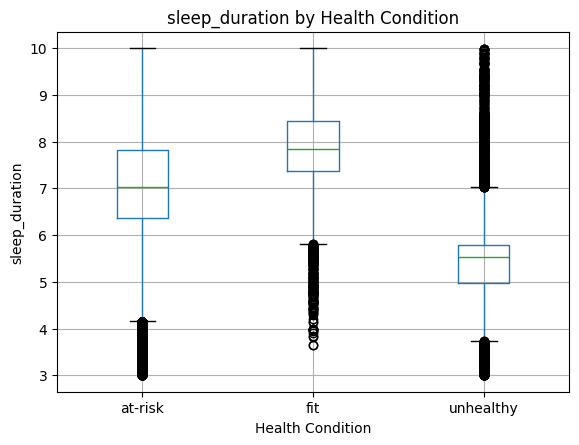

<Figure size 700x400 with 0 Axes>

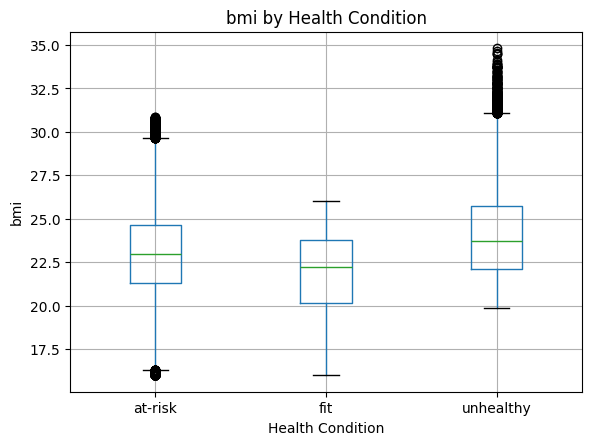

<Figure size 700x400 with 0 Axes>

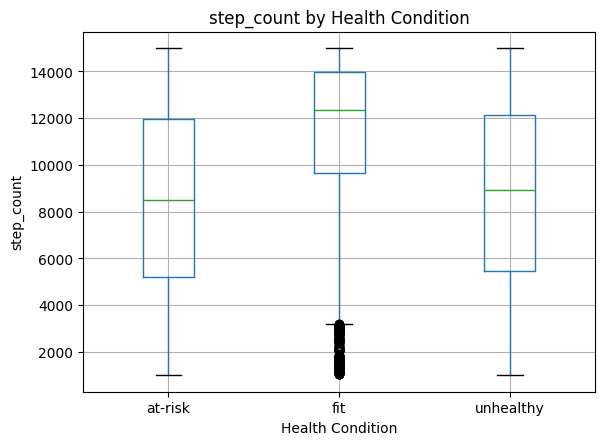

<Figure size 700x400 with 0 Axes>

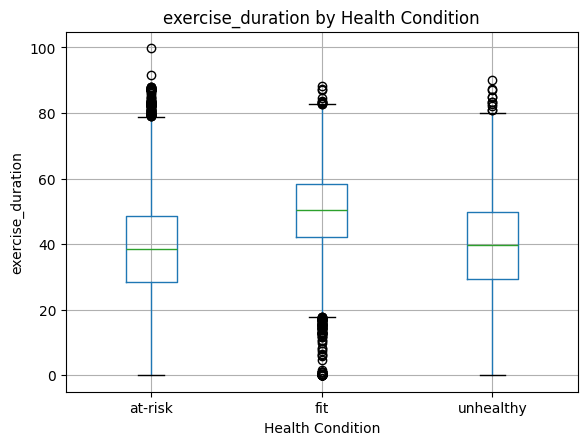

In [ ]:
import matplotlib.pyplot as plt

# 건강 상태별 분포 차이가 커 보였던 수치형 변수
check_cols = [
    "sleep_duration",
    "bmi",
    "step_count",
    "exercise_duration"
]

for col in check_cols:
    plt.figure(figsize=(7, 4))

    train.boxplot(
        column=col,
        by="health_condition"
    )

    plt.title(f"{col} by Health Condition")
    plt.suptitle("")  # pandas가 자동으로 만드는 제목 제거
    plt.xlabel("Health Condition")
    plt.ylabel(col)
    plt.show()

### **2-3. 결측치 확인**

In [ ]:
# 결측치가 있는 모든 변수에 대해
# 결측 여부별 health_condition 비율 비교
# True는 결측치인 행, False는 값이 있는 행

missing_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in missing_cols:
    temp = train.copy()
    temp["is_missing"] = temp[col].isna()

    result = pd.crosstab(
        temp["is_missing"],
        temp["health_condition"],
        normalize="index"
    ) * 100

    print(f"\n===== {col} =====")
    display(result.round(2))


===== sleep_duration =====


health_condition,at-risk,fit,unhealthy
is_missing,,,
False,85.86,5.77,8.37
True,85.93,5.73,8.34



===== heart_rate =====


health_condition,at-risk,fit,unhealthy
is_missing,,,
False,85.85,5.77,8.38
True,87.08,5.53,7.39



===== bmi =====


...

health_condition,at-risk,fit,unhealthy
is_missing,,,
False,85.86,5.77,8.37
True,85.94,5.72,8.34



===== smoking_alcohol =====


health_condition,at-risk,fit,unhealthy
is_missing,,,
False,85.88,5.77,8.36
True,85.68,5.77,8.55



===== gender =====


health_condition,at-risk,fit,unhealthy
is_missing,,,
False,85.87,5.77,8.36
True,85.83,5.57,8.60


In [ ]:
# BMI 결측 여부 변수 생성
train["bmi_missing"] = train["bmi"].isna()

# BMI를 제외한 수치형 변수 평균 비교
compare_num_cols = [
    "sleep_duration",
    "heart_rate",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

train.groupby("bmi_missing")[compare_num_cols].mean().round(2)

,sleep_duration,heart_rate,calorie_expenditure,step_count,exercise_duration,water_intake
bmi_missing,,,,,,
False,6.98,75.1,2226.17,8616.46,38.76,2.19
True,7.56,75.1,2222.03,8591.24,38.58,2.19


In [ ]:
# BMI 결측 여부에 따른 범주형 변수 분포 비교

cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in cat_cols:
    print(f"\n===== {col} =====")

    result = pd.crosstab(
        train["bmi_missing"],
        train[col],
        normalize="index"
    ) * 100

    display(result.round(2))


===== diet_type =====


diet_type,balanced,non-veg,veg
bmi_missing,,,
False,33.21,32.92,33.87
True,33.11,32.85,34.04



===== stress_level =====


stress_level,high,low,medium
bmi_missing,,,
False,29.31,27.59,43.10
True,27.41,28.72,43.88



===== sleep_quality =====


...

physical_activity_level,active,moderate,sedentary
bmi_missing,,,
False,32.54,33.84,33.63
True,32.68,33.29,34.03



===== smoking_alcohol =====


smoking_alcohol,no,occasional,yes
bmi_missing,,,
False,33.19,32.96,33.85
True,35.04,32.72,32.24



===== gender =====


gender,female,male,other
bmi_missing,,,
False,33.51,35.55,30.94
True,32.89,35.67,31.44


In [ ]:
# BMI 결측 집단 -> sleep_quality 값의 실제 개수 확인
train.loc[
    train["bmi_missing"],
    "sleep_quality"
].value_counts(dropna=False)

,count
sleep_quality,
good,12677
NaN,1221


In [ ]:
# sleep_quality -> BMI 결측 비율 확인

result = pd.crosstab(
    train["sleep_quality"],
    train["bmi_missing"],
    normalize="index"
) * 100

result.round(2)

bmi_missing,False,True
sleep_quality,,
average,100.00,0.00
good,93.84,6.16
poor,100.00,0.00


### **3. 전처리**

In [ ]:
# 원본 train을 보존하고 모델용 데이터 생성
X = train.drop(columns=["health_condition", "id"]).copy()
y = train["health_condition"].copy()

print(X.shape)
display(X.head())

(690088, 14)


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,bmi_missing
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,False
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,False
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,False
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,False
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,False


In [ ]:
# 결측치 대체가 필요한 연속형 수치 변수
num_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

# 결측치 처리 + 인코딩이 필요한 범주형 변수
cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]


In [ ]:
from sklearn.model_selection import train_test_split

# train / validation 인덱스를 8:2로 분리
train_idx, val_idx = train_test_split(
    X.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]

In [ ]:
# train / validation 데이터 생성
X_train_final = X.loc[train_idx].copy()
X_val_final = X.loc[val_idx].copy()

# 수치형 missing indicator 추가
for col in num_cols:
    X_train_final[f"{col}_missing"] = X_train_final[col].isna().astype(int)
    X_val_final[f"{col}_missing"] = X_val_final[col].isna().astype(int)

# 수치형 결측치 → train의 중앙값으로 대체
for col in num_cols:
    median_value = X_train_final[col].median()

    X_train_final[col] = X_train_final[col].fillna(median_value)
    X_val_final[col] = X_val_final[col].fillna(median_value)

# 범주형 결측치 → MISSING
for col in cat_cols:
    X_train_final[col] = X_train_final[col].fillna("MISSING")
    X_val_final[col] = X_val_final[col].fillna("MISSING")

# 채택한 파생변수 추가
X_train_final["sleep_bmi"] = (
    X_train_final["sleep_duration"] * X_train_final["bmi"]
)

X_val_final["sleep_bmi"] = (
    X_val_final["sleep_duration"] * X_val_final["bmi"]
)

# 노이즈 피처 제거
X_train_final = X_train_final.drop(
    columns=["gender", "diet_type", "heart_rate", "water_intake"]
)

X_val_final = X_val_final.drop(
    columns=["gender", "diet_type", "heart_rate", "water_intake"]
)

# 남아 있는 범주형 변수
final_cat_cols = [
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol"
]

# One-Hot Encoding
X_train_final = pd.get_dummies(
    X_train_final,
    columns=final_cat_cols,
    drop_first=False
)

X_val_final = pd.get_dummies(
    X_val_final,
    columns=final_cat_cols,
    drop_first=False
)

# train과 validation 컬럼 맞추기
X_val_final = X_val_final.reindex(
    columns=X_train_final.columns,
    fill_value=False
)

print(X_train_final.shape)
print(X_val_final.shape)

(552070, 29)
(138018, 29)


### **4. 모델링**

In [ ]:
# 저장 설정 셀
from google.colab import drive
import os
import joblib
import numpy as np

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/student_health_models"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
#Balanced LightGBM
from lightgbm import LGBMClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report

balanced_model_path = f"{SAVE_DIR}/lgbm_balanced.pkl"

# 저장된 모델이 있으면 불러오기
if os.path.exists(balanced_model_path):
    lgbm_balanced = joblib.load(balanced_model_path)
    print("저장된 Balanced LightGBM을 불러왔습니다.")

# 없으면 새로 학습 후 저장
else:
    lgbm_balanced = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgbm_balanced.fit(X_train_final, y_train)

    joblib.dump(
        lgbm_balanced,
        balanced_model_path
    )

    print("Balanced LightGBM 학습 및 저장 완료.")

# validation 예측
lgbm_balanced_pred = lgbm_balanced.predict(X_val_final)

lgbm_balanced_acc = balanced_accuracy_score(
    y_val,
    lgbm_balanced_pred
)

print("Balanced Accuracy :", f"{lgbm_balanced_acc:.5f}")
print()
print(classification_report(y_val, lgbm_balanced_pred))

저장된 Balanced LightGBM을 불러왔습니다.
Balanced Accuracy : 0.94986

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    118512
         fit       0.74      0.95      0.83      7961
   unhealthy       0.69      0.97      0.80     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.94    138018



In [ ]:
#missing_count 추가 모델
# 원본에서 train / validation 생성
X_train_mc = X.loc[train_idx].copy()
X_val_mc = X.loc[val_idx].copy()

# 행별 결측 개수
X_train_mc["missing_count"] = X_train_mc.isna().sum(axis=1)
X_val_mc["missing_count"] = X_val_mc.isna().sum(axis=1)

# 수치형 missing indicator
for col in num_cols:
    X_train_mc[f"{col}_missing"] = X_train_mc[col].isna().astype(int)
    X_val_mc[f"{col}_missing"] = X_val_mc[col].isna().astype(int)

# 수치형 결측치 → train 중앙값
for col in num_cols:
    median_value = X_train_mc[col].median()

    X_train_mc[col] = X_train_mc[col].fillna(median_value)
    X_val_mc[col] = X_val_mc[col].fillna(median_value)

# 범주형 결측치 → MISSING
for col in cat_cols:
    X_train_mc[col] = X_train_mc[col].fillna("MISSING")
    X_val_mc[col] = X_val_mc[col].fillna("MISSING")

# Sleep × BMI
X_train_mc["sleep_bmi"] = (
    X_train_mc["sleep_duration"] * X_train_mc["bmi"]
)

X_val_mc["sleep_bmi"] = (
    X_val_mc["sleep_duration"] * X_val_mc["bmi"]
)

# 노이즈 피처 제거
drop_cols = [
    "gender",
    "diet_type",
    "heart_rate",
    "water_intake"
]

X_train_mc = X_train_mc.drop(columns=drop_cols)
X_val_mc = X_val_mc.drop(columns=drop_cols)

# One-Hot Encoding
X_train_mc = pd.get_dummies(
    X_train_mc,
    columns=final_cat_cols,
    drop_first=False
)

X_val_mc = pd.get_dummies(
    X_val_mc,
    columns=final_cat_cols,
    drop_first=False
)

# 컬럼 맞추기
X_val_mc = X_val_mc.reindex(
    columns=X_train_mc.columns,
    fill_value=False
)

# 모델 저장 경로
mc_model_path = f"{SAVE_DIR}/lgbm_missing_count.pkl"

# 저장 모델 불러오기
if os.path.exists(mc_model_path):
    lgbm_mc = joblib.load(mc_model_path)
    print("저장된 missing_count 모델을 불러왔습니다.")

# 없으면 학습 후 저장
else:
    lgbm_mc = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgbm_mc.fit(X_train_mc, y_train)

    joblib.dump(
        lgbm_mc,
        mc_model_path
    )

    print("missing_count 모델 학습 및 저장 완료.")

# validation 예측
mc_pred = lgbm_mc.predict(X_val_mc)

mc_bal_acc = balanced_accuracy_score(
    y_val,
    mc_pred
)

print("Balanced LGBM  :", f"{lgbm_balanced_acc:.5f}")
print("+ missing_count:", f"{mc_bal_acc:.5f}")

저장된 missing_count 모델을 불러왔습니다.
Balanced LGBM  : 0.94986
+ missing_count: 0.95001


In [ ]:
#5-Fold CV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

oof_path = f"{SAVE_DIR}/oof_proba.npy"
cv_result_path = f"{SAVE_DIR}/cv_results.pkl"

classes = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

# 저장된 CV 결과가 있으면 바로 불러오기
if os.path.exists(oof_path) and os.path.exists(cv_result_path):

    oof_proba = np.load(oof_path)

    cv_results = joblib.load(cv_result_path)

    fold_scores = cv_results["fold_scores"]
    oof_score = cv_results["oof_score"]

    print("저장된 5-Fold CV 결과를 불러왔습니다.")

# 없으면 5-Fold CV 실행
else:

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_proba = np.zeros((len(X), 3))
    fold_scores = []

    for fold, (train_idx_cv, val_idx_cv) in enumerate(
        skf.split(X, y), 1
    ):

        X_tr = X.iloc[train_idx_cv].copy()
        X_va = X.iloc[val_idx_cv].copy()

        y_tr = y.iloc[train_idx_cv]
        y_va = y.iloc[val_idx_cv]

        # missing_count
        X_tr["missing_count"] = X_tr.isna().sum(axis=1)
        X_va["missing_count"] = X_va.isna().sum(axis=1)

        # missing indicator
        for col in num_cols:
            X_tr[f"{col}_missing"] = X_tr[col].isna().astype(int)
            X_va[f"{col}_missing"] = X_va[col].isna().astype(int)

        # 수치형 결측치
        for col in num_cols:
            median_value = X_tr[col].median()

            X_tr[col] = X_tr[col].fillna(median_value)
            X_va[col] = X_va[col].fillna(median_value)

        # 범주형 결측치
        for col in cat_cols:
            X_tr[col] = X_tr[col].fillna("MISSING")
            X_va[col] = X_va[col].fillna("MISSING")

        # Sleep × BMI
        X_tr["sleep_bmi"] = (
            X_tr["sleep_duration"] * X_tr["bmi"]
        )

        X_va["sleep_bmi"] = (
            X_va["sleep_duration"] * X_va["bmi"]
        )

        # 노이즈 피처 제거
        X_tr = X_tr.drop(columns=drop_cols)
        X_va = X_va.drop(columns=drop_cols)

        # One-Hot Encoding
        X_tr = pd.get_dummies(
            X_tr,
            columns=final_cat_cols,
            drop_first=False
        )

        X_va = pd.get_dummies(
            X_va,
            columns=final_cat_cols,
            drop_first=False
        )

        X_va = X_va.reindex(
            columns=X_tr.columns,
            fill_value=False
        )

        # Balanced LightGBM
        model_cv = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model_cv.fit(X_tr, y_tr)

        # 확률 예측
        fold_proba = model_cv.predict_proba(X_va)

        order = [
            list(model_cv.classes_).index(c)
            for c in classes
        ]

        fold_proba = fold_proba[:, order]

        oof_proba[val_idx_cv] = fold_proba

        # Fold 점수
        fold_pred = classes[
            np.argmax(fold_proba, axis=1)
        ]

        fold_score = balanced_accuracy_score(
            y_va,
            fold_pred
        )

        fold_scores.append(fold_score)

        print(
            f"Fold {fold}: {fold_score:.5f}"
        )

    # 전체 OOF
    oof_pred = classes[
        np.argmax(oof_proba, axis=1)
    ]

    oof_score = balanced_accuracy_score(
        y,
        oof_pred
    )

    # 결과 저장
    np.save(
        oof_path,
        oof_proba
    )

    joblib.dump(
        {
            "fold_scores": fold_scores,
            "oof_score": oof_score
        },
        cv_result_path
    )

    print("5-Fold CV 결과 저장 완료.")

print()
print("Fold 평균      :", f"{np.mean(fold_scores):.5f}")
print("Fold 표준편차  :", f"{np.std(fold_scores):.5f}")
print("전체 OOF       :", f"{oof_score:.5f}")

저장된 5-Fold CV 결과를 불러왔습니다.

Fold 평균      : 0.94927
Fold 표준편차  : 0.00115
전체 OOF       : 0.94927


In [ ]:
#OOF multiplier
multiplier_path = f"{SAVE_DIR}/multiplier_results.pkl"

if os.path.exists(multiplier_path):

    multiplier_results = joblib.load(
        multiplier_path
    )

    best_oof_score = multiplier_results["best_oof_score"]
    best_oof_weights = multiplier_results["best_oof_weights"]

    print("저장된 Multiplier 결과를 불러왔습니다.")

else:

    best_oof_score = oof_score
    best_oof_weights = (1.0, 1.0, 1.0)

    weight_range = np.arange(
        0.90,
        1.11,
        0.01
    )

    for fit_w in weight_range:
        for unhealthy_w in weight_range:

            weights = np.array([
                1.0,
                fit_w,
                unhealthy_w
            ])

            adjusted_proba = oof_proba * weights

            pred_idx = np.argmax(
                adjusted_proba,
                axis=1
            )

            adjusted_pred = classes[
                pred_idx
            ]

            score = balanced_accuracy_score(
                y,
                adjusted_pred
            )

            if score > best_oof_score:
                best_oof_score = score
                best_oof_weights = (
                    1.0,
                    fit_w,
                    unhealthy_w
                )

    joblib.dump(
        {
            "best_oof_score": best_oof_score,
            "best_oof_weights": best_oof_weights
        },
        multiplier_path
    )

    print("Multiplier 탐색 및 저장 완료.")

print("기본 OOF       :", f"{oof_score:.5f}")
print("Multiplier OOF :", f"{best_oof_score:.5f}")
print("Best weights   :", best_oof_weights)

저장된 Multiplier 결과를 불러왔습니다.
기본 OOF       : 0.94927
Multiplier OOF : 0.94937
Best weights   : (1.0, np.float64(0.9500000000000001), np.float64(1.1))


In [ ]:
# [실험 목적]
# 현재 HR/Water 복원 버전에 gender, diet_type까지 다시 포함했을 때
# Balanced LightGBM 성능이 추가로 개선되는지 확인

# 원본에서 train / validation 생성
X_train_all_restore = X.loc[train_idx].copy()
X_val_all_restore = X.loc[val_idx].copy()

# 행별 결측 개수
X_train_all_restore["missing_count"] = X_train_all_restore.isna().sum(axis=1)
X_val_all_restore["missing_count"] = X_val_all_restore.isna().sum(axis=1)

# 수치형 missing indicator
for col in num_cols:
    X_train_all_restore[f"{col}_missing"] = X_train_all_restore[col].isna().astype(int)
    X_val_all_restore[f"{col}_missing"] = X_val_all_restore[col].isna().astype(int)

# 수치형 결측치 → train 중앙값
for col in num_cols:
    median_value = X_train_all_restore[col].median()

    X_train_all_restore[col] = X_train_all_restore[col].fillna(median_value)
    X_val_all_restore[col] = X_val_all_restore[col].fillna(median_value)

# 범주형 결측치 → MISSING
for col in cat_cols:
    X_train_all_restore[col] = X_train_all_restore[col].fillna("MISSING")
    X_val_all_restore[col] = X_val_all_restore[col].fillna("MISSING")

# 기존 채택 파생변수
X_train_all_restore["sleep_bmi"] = (
    X_train_all_restore["sleep_duration"] * X_train_all_restore["bmi"]
)

X_val_all_restore["sleep_bmi"] = (
    X_val_all_restore["sleep_duration"] * X_val_all_restore["bmi"]
)

# 이번에는 모든 원본 변수 유지
all_restore_cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

# One-Hot Encoding
X_train_all_restore = pd.get_dummies(
    X_train_all_restore,
    columns=all_restore_cat_cols,
    drop_first=False
)

X_val_all_restore = pd.get_dummies(
    X_val_all_restore,
    columns=all_restore_cat_cols,
    drop_first=False
)

# 컬럼 맞추기
X_val_all_restore = X_val_all_restore.reindex(
    columns=X_train_all_restore.columns,
    fill_value=False
)

# 모델 저장 경로
all_restore_model_path = f"{SAVE_DIR}/lgbm_restore_all_features.pkl"

# 저장된 모델이 있으면 불러오기
if os.path.exists(all_restore_model_path):
    lgbm_all_restore = joblib.load(all_restore_model_path)
    print("저장된 전체 변수 복원 모델을 불러왔습니다.")

# 없으면 학습 후 저장
else:
    lgbm_all_restore = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgbm_all_restore.fit(
        X_train_all_restore,
        y_train
    )

    joblib.dump(
        lgbm_all_restore,
        all_restore_model_path
    )

    print("전체 변수 복원 모델 학습 및 저장 완료.")

# validation 예측
all_restore_pred = lgbm_all_restore.predict(
    X_val_all_restore
)

all_restore_bal_acc = balanced_accuracy_score(
    y_val,
    all_restore_pred
)

print("기존 missing_count :", f"{mc_bal_acc:.5f}")
print("+ HR/Water 복원     :", f"{restore_bal_acc:.5f}")
print("+ 전체 변수 복원    :", f"{all_restore_bal_acc:.5f}")

저장된 전체 변수 복원 모델을 불러왔습니다.
기존 missing_count : 0.95001


NameError: name 'restore_bal_acc' is not defined

In [ ]:
# [실험 목적]
# 현재 최고 구조인 '전체 변수 복원 + missing_count + sleep_bmi' 모델을
# 5-Fold Stratified CV로 검증해 단일 validation의 개선이 실제로 재현되는지 확인
# 기존 OOF 기준: 0.94927

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd
import os
import joblib

# 기존 CV와 파일이 겹치지 않도록 새 이름 사용
cv_result_path = f"{SAVE_DIR}/cv_all_features_v2.pkl"
oof_path = f"{SAVE_DIR}/oof_proba_all_features_v2.npy"

# 저장된 결과가 있으면 불러오기
if os.path.exists(cv_result_path) and os.path.exists(oof_path):

    cv_results = joblib.load(cv_result_path)
    oof_proba_all = np.load(oof_path)

    fold_scores_all = cv_results["fold_scores"]
    oof_score_all = cv_results["oof_score"]
    classes_all = np.array(cv_results["classes"])

    print("저장된 전체 변수 5-Fold CV 결과를 불러왔습니다.")

else:

    # 혹시 id가 남아 있다면 제외
    X_cv = X.drop(columns=["id"], errors="ignore").copy()

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    classes_all = np.sort(y.unique())

    oof_proba_all = np.zeros(
        (len(X_cv), len(classes_all))
    )

    fold_scores_all = []

    for fold, (train_idx_cv, val_idx_cv) in enumerate(
        skf.split(X_cv, y),
        1
    ):

        print(f"\nFold {fold}/5")

        X_tr = X_cv.iloc[train_idx_cv].copy()
        X_va = X_cv.iloc[val_idx_cv].copy()

        y_tr = y.iloc[train_idx_cv]
        y_va = y.iloc[val_idx_cv]

        # 행별 결측 개수
        X_tr["missing_count"] = X_tr.isna().sum(axis=1)
        X_va["missing_count"] = X_va.isna().sum(axis=1)

        # 수치형 missing indicator
        for col in num_cols:
            X_tr[f"{col}_missing"] = X_tr[col].isna().astype(int)
            X_va[f"{col}_missing"] = X_va[col].isna().astype(int)

        # 수치형 결측치 → 해당 Fold train의 중앙값
        for col in num_cols:
            median_value = X_tr[col].median()

            X_tr[col] = X_tr[col].fillna(median_value)
            X_va[col] = X_va[col].fillna(median_value)

        # 범주형 결측치 → MISSING
        for col in cat_cols:
            X_tr[col] = X_tr[col].fillna("MISSING")
            X_va[col] = X_va[col].fillna("MISSING")

        # 기존 채택 파생변수
        X_tr["sleep_bmi"] = (
            X_tr["sleep_duration"] * X_tr["bmi"]
        )

        X_va["sleep_bmi"] = (
            X_va["sleep_duration"] * X_va["bmi"]
        )

        # 모든 범주형 변수 One-Hot Encoding
        X_tr = pd.get_dummies(
            X_tr,
            columns=cat_cols,
            drop_first=False
        )

        X_va = pd.get_dummies(
            X_va,
            columns=cat_cols,
            drop_first=False
        )

        # Validation 컬럼을 Train 기준으로 맞춤
        X_va = X_va.reindex(
            columns=X_tr.columns,
            fill_value=False
        )

        # 현재 기준 LightGBM
        model = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_tr,
            y_tr
        )

        val_pred = model.predict(X_va)
        val_proba = model.predict_proba(X_va)

        fold_score = balanced_accuracy_score(
            y_va,
            val_pred
        )

        fold_scores_all.append(fold_score)

        # predict_proba 컬럼 순서 맞추기
        class_order = [
            np.where(classes_all == c)[0][0]
            for c in model.classes_
        ]

        for model_col, target_col in enumerate(class_order):
            oof_proba_all[
                val_idx_cv,
                target_col
            ] = val_proba[:, model_col]

        print(
            "Balanced Accuracy:",
            f"{fold_score:.5f}"
        )

    # 전체 OOF 예측
    oof_pred_idx = np.argmax(
        oof_proba_all,
        axis=1
    )

    oof_pred_all = classes_all[
        oof_pred_idx
    ]

    oof_score_all = balanced_accuracy_score(
        y,
        oof_pred_all
    )

    # 결과 저장
    np.save(
        oof_path,
        oof_proba_all
    )

    joblib.dump(
        {
            "fold_scores": fold_scores_all,
            "oof_score": oof_score_all,
            "classes": classes_all.tolist()
        },
        cv_result_path
    )

    print("\n전체 변수 5-Fold CV 결과 저장 완료.")

print("\nFold Scores:")
for i, score in enumerate(fold_scores_all, 1):
    print(
        f"Fold {i}:",
        f"{score:.5f}"
    )

print(
    "\nMean:",
    f"{np.mean(fold_scores_all):.5f}"
)

print(
    "Std :",
    f"{np.std(fold_scores_all):.5f}"
)

print(
    "OOF :",
    f"{oof_score_all:.5f}"
)

print(
    "기존 OOF:",
    "0.94927"
)

저장된 전체 변수 5-Fold CV 결과를 불러왔습니다.

Fold Scores:
Fold 1: 0.95039
Fold 2: 0.95147
Fold 3: 0.94859
Fold 4: 0.94935
Fold 5: 0.94771

Mean: 0.94950
Std : 0.00132
OOF : 0.94950
기존 OOF: 0.94927


In [ ]:
# [실험 목적]
# 새 전체 변수 복원 5-Fold OOF 확률에 decision-time multiplier를 적용해
# Balanced Accuracy가 추가로 개선되는지 확인
# 이전 탐색에서 unhealthy 최적값이 범위 상단 1.10이었으므로 주변 범위를 확장

multiplier_all_path = (
    f"{SAVE_DIR}/multiplier_all_features_v2.pkl"
)

if os.path.exists(multiplier_all_path):

    multiplier_all_results = joblib.load(
        multiplier_all_path
    )

    best_multiplier_score = (
        multiplier_all_results["best_score"]
    )

    best_multiplier_weights = (
        multiplier_all_results["best_weights"]
    )

    print("저장된 새 Multiplier 결과를 불러왔습니다.")

else:

    best_multiplier_score = oof_score_all
    best_multiplier_weights = (1.0, 1.0, 1.0)

    # 이전 결과를 참고해 좁은 범위만 탐색
    fit_range = np.arange(
        0.90,
        1.01,
        0.01
    )

    unhealthy_range = np.arange(
        1.05,
        1.26,
        0.01
    )

    for fit_w in fit_range:
        for unhealthy_w in unhealthy_range:

            weights = np.array([
                1.0,
                fit_w,
                unhealthy_w
            ])

            adjusted_proba = (
                oof_proba_all * weights
            )

            pred_idx = np.argmax(
                adjusted_proba,
                axis=1
            )

            adjusted_pred = classes_all[
                pred_idx
            ]

            score = balanced_accuracy_score(
                y,
                adjusted_pred
            )

            if score > best_multiplier_score:

                best_multiplier_score = score

                best_multiplier_weights = (
                    1.0,
                    float(fit_w),
                    float(unhealthy_w)
                )

    joblib.dump(
        {
            "best_score": best_multiplier_score,
            "best_weights": best_multiplier_weights
        },
        multiplier_all_path
    )

    print("새 Multiplier 탐색 및 저장 완료.")

print(
    "기본 OOF       :",
    f"{oof_score_all:.5f}"
)

print(
    "Multiplier OOF :",
    f"{best_multiplier_score:.5f}"
)

print(
    "Best weights   :",
    best_multiplier_weights
)

저장된 새 Multiplier 결과를 불러왔습니다.
기본 OOF       : 0.94950
Multiplier OOF : 0.94966
Best weights   : (1.0, 0.9600000000000001, 1.2300000000000002)


In [ ]:
# [실험 목적]
# 13개 원본 변수 각각의 '정확히 같은 값(exact value)'에 대해
# 3개 클래스 확률을 Target Encoding으로 생성하고,
# 원본 13개 + TE 39개를 HGBC에 학습해 5-Fold OOF 성능을 확인
#
# 중요:
# - Outer Validation의 정답은 TE 생성에 절대 사용하지 않음
# - Outer Train의 TE도 내부 3-Fold OOF 방식으로 생성
# - 장시간 실행을 고려해 Outer Fold마다 진행상황 자동 저장
#
# 현재 비교 기준:
# LightGBM 기본 OOF      = 0.94950
# LightGBM + Multiplier = 0.94966

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score

import numpy as np
import pandas as pd
import os
import joblib

# -----------------------------
# 기본 설정
# -----------------------------

X_te = X.drop(columns=["id"], errors="ignore").copy()
y_te = y.reset_index(drop=True)
X_te = X_te.reset_index(drop=True)

classes_te = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

feature_cols = list(X_te.columns)

te_cols = [
    f"TE_{col}_{cls}"
    for col in feature_cols
    for cls in classes_te
]

progress_path = (
    f"{SAVE_DIR}/te_hgbc_5fold_progress_v1.pkl"
)

final_path = (
    f"{SAVE_DIR}/te_hgbc_5fold_results_v1.pkl"
)

oof_path = (
    f"{SAVE_DIR}/te_hgbc_oof_proba_v1.npy"
)


# -----------------------------
# exact value key 생성 함수
# -----------------------------

def make_key(series):
    return (
        series.astype("object")
        .where(series.notna(), "__MISSING__")
        .astype(str)
    )


# -----------------------------
# TE mapping 생성 함수
# -----------------------------

def make_te_mapping(X_part, y_part, columns, classes):

    mappings = {}

    global_prior = (
        y_part.value_counts(normalize=True)
        .reindex(classes)
        .fillna(0)
    )

    for col in columns:

        key = make_key(X_part[col])

        temp = pd.DataFrame({
            "key": key.values,
            "target": y_part.values
        })

        table = pd.crosstab(
            temp["key"],
            temp["target"],
            normalize="index"
        )

        table = table.reindex(
            columns=classes,
            fill_value=0
        )

        mappings[col] = table

    return mappings, global_prior


# -----------------------------
# mapping 적용 함수
# -----------------------------

def apply_te(
    X_part,
    mappings,
    global_prior,
    columns,
    classes
):

    result = pd.DataFrame(
        index=X_part.index
    )

    for col in columns:

        key = make_key(X_part[col])

        table = mappings[col]

        for cls in classes:

            result[
                f"TE_{col}_{cls}"
            ] = (
                key.map(table[cls])
                .fillna(global_prior[cls])
                .astype("float32")
                .values
            )

    return result


# -----------------------------
# 저장 결과가 있으면 불러오기
# -----------------------------

if (
    os.path.exists(final_path)
    and os.path.exists(oof_path)
):

    results = joblib.load(final_path)

    te_hgbc_fold_scores = results[
        "fold_scores"
    ]

    te_hgbc_oof_score = results[
        "oof_score"
    ]

    oof_proba_te_hgbc = np.load(
        oof_path
    )

    print(
        "저장된 TE-HGBC 최종 결과를 불러왔습니다."
    )

else:

    outer_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_proba_te_hgbc = np.zeros(
        (
            len(X_te),
            len(classes_te)
        ),
        dtype=np.float32
    )

    te_hgbc_fold_scores = []
    completed_folds = []

    # 이전 진행상황 있으면 복구
    if os.path.exists(progress_path):

        progress = joblib.load(
            progress_path
        )

        oof_proba_te_hgbc = progress[
            "oof_proba"
        ]

        te_hgbc_fold_scores = progress[
            "fold_scores"
        ]

        completed_folds = progress[
            "completed_folds"
        ]

        print(
            "이전 TE-HGBC 진행상황을 불러왔습니다."
        )

    for outer_fold, (
        train_idx_outer,
        val_idx_outer
    ) in enumerate(
        outer_cv.split(X_te, y_te),
        1
    ):

        if outer_fold in completed_folds:

            print(
                f"Fold {outer_fold}/5 이미 완료 → 건너뜀"
            )
            continue

        print(
            f"\n===== Outer Fold {outer_fold}/5 ====="
        )

        X_tr_raw = (
            X_te.iloc[train_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        X_va_raw = (
            X_te.iloc[val_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        y_tr = (
            y_te.iloc[train_idx_outer]
            .reset_index(drop=True)
        )

        y_va = (
            y_te.iloc[val_idx_outer]
            .reset_index(drop=True)
        )

        # -----------------------------
        # Outer Train 내부 3-Fold OOF TE
        # -----------------------------

        X_tr_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_tr_raw),
                    len(te_cols)
                ),
                dtype=np.float32
            ),
            columns=te_cols
        )

        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=42
        )

        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_tr_raw,
                y_tr
            ),
            1
        ):

            print(
                f"  Inner TE Fold {inner_fold}/3"
            )

            X_inner_train = (
                X_tr_raw.iloc[
                    inner_train_idx
                ]
            )

            y_inner_train = (
                y_tr.iloc[
                    inner_train_idx
                ]
            )

            X_inner_val = (
                X_tr_raw.iloc[
                    inner_val_idx
                ]
            )

            mappings, global_prior = (
                make_te_mapping(
                    X_inner_train,
                    y_inner_train,
                    feature_cols,
                    classes_te
                )
            )

            encoded_inner_val = apply_te(
                X_inner_val,
                mappings,
                global_prior,
                feature_cols,
                classes_te
            )

            X_tr_te.iloc[
                inner_val_idx
            ] = encoded_inner_val.values

        # -----------------------------
        # Outer Validation TE
        # Outer Train 전체로 mapping 생성
        # -----------------------------

        mappings_outer, prior_outer = (
            make_te_mapping(
                X_tr_raw,
                y_tr,
                feature_cols,
                classes_te
            )
        )

        X_va_te = apply_te(
            X_va_raw,
            mappings_outer,
            prior_outer,
            feature_cols,
            classes_te
        ).reset_index(drop=True)

        # -----------------------------
        # 원본 변수 전처리
        # -----------------------------

        X_tr_base = X_tr_raw.copy()
        X_va_base = X_va_raw.copy()

        # 수치형 → Train median
        for col in num_cols:

            median_value = (
                X_tr_base[col].median()
            )

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna(median_value)
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna(median_value)
            )

        # 범주형 → MISSING
        for col in cat_cols:

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna("MISSING")
                .astype(str)
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna("MISSING")
                .astype(str)
            )

        # 범주형 Ordinal Encoding
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        X_tr_base[cat_cols] = (
            encoder.fit_transform(
                X_tr_base[cat_cols]
            )
        )

        X_va_base[cat_cols] = (
            encoder.transform(
                X_va_base[cat_cols]
            )
        )

        # -----------------------------
        # 원본 13개 + TE 39개 결합
        # -----------------------------

        X_tr_final = pd.concat(
            [
                X_tr_base.reset_index(
                    drop=True
                ),
                X_tr_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        X_va_final = pd.concat(
            [
                X_va_base.reset_index(
                    drop=True
                ),
                X_va_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        print(
            "  최종 Feature 수:",
            X_tr_final.shape[1]
        )

        # -----------------------------
        # HGBC
        # -----------------------------

        model = HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=42
        )

        model.fit(
            X_tr_final,
            y_tr
        )

        val_proba = model.predict_proba(
            X_va_final
        )

        # 클래스 순서 맞추기
        aligned_proba = np.zeros(
            (
                len(X_va_final),
                len(classes_te)
            ),
            dtype=np.float32
        )

        for model_col, cls in enumerate(
            model.classes_
        ):

            target_col = np.where(
                classes_te == cls
            )[0][0]

            aligned_proba[
                :,
                target_col
            ] = val_proba[
                :,
                model_col
            ]

        oof_proba_te_hgbc[
            val_idx_outer
        ] = aligned_proba

        val_pred = classes_te[
            np.argmax(
                aligned_proba,
                axis=1
            )
        ]

        fold_score = (
            balanced_accuracy_score(
                y_va,
                val_pred
            )
        )

        te_hgbc_fold_scores.append(
            fold_score
        )

        completed_folds.append(
            outer_fold
        )

        print(
            "  Balanced Accuracy:",
            f"{fold_score:.5f}"
        )

        # Fold마다 진행상황 저장
        joblib.dump(
            {
                "oof_proba":
                    oof_proba_te_hgbc,
                "fold_scores":
                    te_hgbc_fold_scores,
                "completed_folds":
                    completed_folds
            },
            progress_path
        )

        print(
            "  Fold 진행상황 저장 완료"
        )

    # -----------------------------
    # 최종 OOF
    # -----------------------------

    final_pred = classes_te[
        np.argmax(
            oof_proba_te_hgbc,
            axis=1
        )
    ]

    te_hgbc_oof_score = (
        balanced_accuracy_score(
            y_te,
            final_pred
        )
    )

    np.save(
        oof_path,
        oof_proba_te_hgbc
    )

    joblib.dump(
        {
            "fold_scores":
                te_hgbc_fold_scores,
            "oof_score":
                te_hgbc_oof_score,
            "classes":
                classes_te.tolist()
        },
        final_path
    )

    print(
        "\nTE-HGBC 최종 결과 저장 완료."
    )


# -----------------------------
# 결과 출력
# -----------------------------

print("\nFold Scores:")

for i, score in enumerate(
    te_hgbc_fold_scores,
    1
):

    print(
        f"Fold {i}:",
        f"{score:.5f}"
    )

print(
    "\nMean:",
    f"{np.mean(te_hgbc_fold_scores):.5f}"
)

print(
    "Std :",
    f"{np.std(te_hgbc_fold_scores):.5f}"
)

print(
    "OOF :",
    f"{te_hgbc_oof_score:.5f}"
)

print(
    "\n현재 LightGBM OOF        : 0.94950"
)

print(
    "LightGBM + Multiplier    : 0.94966"
)

저장된 TE-HGBC 최종 결과를 불러왔습니다.

Fold Scores:
Fold 1: 0.95083
Fold 2: 0.95217
Fold 3: 0.94928
Fold 4: 0.94948
Fold 5: 0.94876

Mean: 0.95010
Std : 0.00124
OOF : 0.95010

현재 LightGBM OOF        : 0.94950
LightGBM + Multiplier    : 0.94966


In [ ]:
# [실험 목적]
# TE-HGBC의 OOF 확률에 클래스별 multiplier를 적용해
# Balanced Accuracy가 0.95010보다 더 개선되는지 확인
# 모델 재학습 없음 → 저장된 OOF 확률만 사용

te_multiplier_path = (
    f"{SAVE_DIR}/te_hgbc_multiplier_results_v1.pkl"
)

if os.path.exists(te_multiplier_path):

    te_multiplier_results = joblib.load(
        te_multiplier_path
    )

    best_te_score = (
        te_multiplier_results["best_score"]
    )

    best_te_weights = (
        te_multiplier_results["best_weights"]
    )

    print(
        "저장된 TE-HGBC Multiplier 결과를 불러왔습니다."
    )

else:

    best_te_score = te_hgbc_oof_score
    best_te_weights = (1.0, 1.0, 1.0)

    # 너무 넓게 돌리지 않고
    # 현재 모델 주변에서 적당히 탐색
    fit_range = np.arange(
        0.85,
        1.11,
        0.01
    )

    unhealthy_range = np.arange(
        0.90,
        1.31,
        0.01
    )

    for fit_w in fit_range:
        for unhealthy_w in unhealthy_range:

            weights = np.array([
                1.0,
                fit_w,
                unhealthy_w
            ])

            adjusted_proba = (
                oof_proba_te_hgbc * weights
            )

            pred_idx = np.argmax(
                adjusted_proba,
                axis=1
            )

            adjusted_pred = classes_te[
                pred_idx
            ]

            score = balanced_accuracy_score(
                y_te,
                adjusted_pred
            )

            if score > best_te_score:

                best_te_score = score

                best_te_weights = (
                    1.0,
                    float(fit_w),
                    float(unhealthy_w)
                )

    joblib.dump(
        {
            "best_score": best_te_score,
            "best_weights": best_te_weights
        },
        te_multiplier_path
    )

    print(
        "TE-HGBC Multiplier 탐색 및 저장 완료."
    )

print(
    "기본 TE-HGBC OOF :",
    f"{te_hgbc_oof_score:.5f}"
)

print(
    "Multiplier OOF   :",
    f"{best_te_score:.5f}"
)

print(
    "Best weights     :",
    best_te_weights
)

저장된 TE-HGBC Multiplier 결과를 불러왔습니다.
기본 TE-HGBC OOF : 0.95010
Multiplier OOF   : 0.95023
Best weights     : (1.0, 0.9, 1.04)


In [ ]:
# [실험 목적]
# LightGBM과 TE-HGBC의 OOF 예측 확률을 가중평균해
# 두 모델이 서로의 오답을 보완하는지 확인
# 모델 재학습 없음 → 저장된 OOF 확률만 사용

blend_path = f"{SAVE_DIR}/lgbm_te_hgbc_blend_v1.pkl"

if os.path.exists(blend_path):

    blend_results = joblib.load(blend_path)

    best_blend_score = blend_results["best_score"]
    best_alpha = blend_results["best_alpha"]

    print("저장된 Blend 결과를 불러왔습니다.")

else:

    # 두 OOF 확률의 클래스 순서 확인
    print("LightGBM classes:", classes_all)
    print("TE-HGBC classes :", classes_te)

    assert np.array_equal(
        classes_all,
        classes_te
    ), "두 모델의 클래스 순서가 다릅니다."

    best_blend_score = -1
    best_alpha = None

    # alpha = TE-HGBC 비중
    # 0.0 → LightGBM 100%
    # 1.0 → TE-HGBC 100%
    alpha_range = np.arange(
        0.0,
        1.01,
        0.05
    )

    for alpha in alpha_range:

        blend_proba = (
            (1 - alpha) * oof_proba_all
            + alpha * oof_proba_te_hgbc
        )

        pred_idx = np.argmax(
            blend_proba,
            axis=1
        )

        blend_pred = classes_all[
            pred_idx
        ]

        score = balanced_accuracy_score(
            y,
            blend_pred
        )

        print(
            f"TE 비중 {alpha:.2f} ->",
            f"{score:.5f}"
        )

        if score > best_blend_score:

            best_blend_score = score
            best_alpha = float(alpha)

    joblib.dump(
        {
            "best_score": best_blend_score,
            "best_alpha": best_alpha
        },
        blend_path
    )

    print("Blend 탐색 및 저장 완료.")

print()
print(
    "LightGBM 기본 OOF :",
    f"{oof_score_all:.5f}"
)

print(
    "TE-HGBC 기본 OOF :",
    f"{te_hgbc_oof_score:.5f}"
)

print(
    "Best Blend OOF   :",
    f"{best_blend_score:.5f}"
)

print(
    "Best TE 비중     :",
    best_alpha
)

저장된 Blend 결과를 불러왔습니다.

LightGBM 기본 OOF : 0.94950
TE-HGBC 기본 OOF : 0.95010
Best Blend OOF   : 0.95028
Best TE 비중     : 0.6000000000000001


In [ ]:
# [실험 목적]
# LightGBM 40% + TE-HGBC 60% 최적 Blend 확률에
# 클래스별 multiplier를 적용해 Balanced Accuracy를 추가 개선
# 모델 재학습 없음

blend_multiplier_path = (
    f"{SAVE_DIR}/lgbm_te_hgbc_blend_multiplier_v1.pkl"
)

if os.path.exists(blend_multiplier_path):

    blend_multiplier_results = joblib.load(
        blend_multiplier_path
    )

    best_blend_mult_score = (
        blend_multiplier_results["best_score"]
    )

    best_blend_mult_weights = (
        blend_multiplier_results["best_weights"]
    )

    print(
        "저장된 Blend Multiplier 결과를 불러왔습니다."
    )

else:

    # 최적 blend 확률 생성
    best_blend_proba = (
        (1 - best_alpha) * oof_proba_all
        + best_alpha * oof_proba_te_hgbc
    )

    best_blend_mult_score = best_blend_score
    best_blend_mult_weights = (1.0, 1.0, 1.0)

    # 너무 넓게 잡지 않고 주변 탐색
    fit_range = np.arange(
        0.85,
        1.06,
        0.01
    )

    unhealthy_range = np.arange(
        0.95,
        1.21,
        0.01
    )

    for fit_w in fit_range:
        for unhealthy_w in unhealthy_range:

            weights = np.array([
                1.0,
                fit_w,
                unhealthy_w
            ])

            adjusted_proba = (
                best_blend_proba * weights
            )

            pred_idx = np.argmax(
                adjusted_proba,
                axis=1
            )

            adjusted_pred = classes_all[
                pred_idx
            ]

            score = balanced_accuracy_score(
                y,
                adjusted_pred
            )

            if score > best_blend_mult_score:

                best_blend_mult_score = score

                best_blend_mult_weights = (
                    1.0,
                    float(fit_w),
                    float(unhealthy_w)
                )

    joblib.dump(
        {
            "best_score": best_blend_mult_score,
            "best_weights": best_blend_mult_weights,
            "best_alpha": best_alpha
        },
        blend_multiplier_path
    )

    print(
        "Blend Multiplier 탐색 및 저장 완료."
    )

print(
    "기본 Blend OOF     :",
    f"{best_blend_score:.5f}"
)

print(
    "Multiplier Blend   :",
    f"{best_blend_mult_score:.5f}"
)

print(
    "Best weights       :",
    best_blend_mult_weights
)

print(
    "TE-HGBC 비중       :",
    best_alpha
)

저장된 Blend Multiplier 결과를 불러왔습니다.
기본 Blend OOF     : 0.95028
Multiplier Blend   : 0.95033
Best weights       : (1.0, 0.9900000000000001, 1.05)
TE-HGBC 비중       : 0.6000000000000001


In [ ]:
# [실험 목적]
# 현재 TE-HGBC + sleep_bmi + calorie_per_step 버전에
# sleep_stress_bmi = sleep_duration × stress_level(ordinal) × bmi 파생변수를 추가해
# 조합 효과가 있는지 확인
#
# 현재 기준:
# 기본 TE-HGBC                  = 0.95010
# + sleep_bmi                   = 0.95015
# + calorie_per_step            = 0.95016
#
# 이번 실험에서는 기존 두 파생변수는 유지하고
# sleep_stress_bmi만 추가

X_te_ssb = X.drop(columns=["id"], errors="ignore").copy()
y_te_ssb = y.reset_index(drop=True)

X_te_ssb = X_te_ssb.reset_index(drop=True)

# 기존 파생변수
X_te_ssb["sleep_bmi"] = (
    X_te_ssb["sleep_duration"]
    * X_te_ssb["bmi"]
)

X_te_ssb["calorie_per_step"] = (
    X_te_ssb["calorie_expenditure"]
    / X_te_ssb["step_count"].replace(0, np.nan)
)

# stress_level을 순서형 숫자로 변환
stress_map = {
    "low": 0,
    "medium": 1,
    "high": 2
}

stress_numeric = (
    X_te_ssb["stress_level"]
    .map(stress_map)
)

# 새 파생변수
X_te_ssb["sleep_stress_bmi"] = (
    X_te_ssb["sleep_duration"]
    * stress_numeric
    * X_te_ssb["bmi"]
)

classes_te_ssb = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

feature_cols_ssb = list(
    X_te_ssb.columns
)

te_cols_ssb = [
    f"TE_{col}_{cls}"
    for col in feature_cols_ssb
    for cls in classes_te_ssb
]

progress_path_ssb = (
    f"{SAVE_DIR}/te_hgbc_sleep_bmi_cps_ssb_progress_v1.pkl"
)

final_path_ssb = (
    f"{SAVE_DIR}/te_hgbc_sleep_bmi_cps_ssb_results_v1.pkl"
)

oof_path_ssb = (
    f"{SAVE_DIR}/te_hgbc_sleep_bmi_cps_ssb_oof_v1.npy"
)


def make_key_ssb(series):
    return (
        series.astype("object")
        .where(series.notna(), "__MISSING__")
        .astype(str)
    )


def make_te_mapping_ssb(
    X_part,
    y_part,
    columns,
    classes
):

    mappings = {}

    global_prior = (
        y_part.value_counts(normalize=True)
        .reindex(classes)
        .fillna(0)
    )

    for col in columns:

        key = make_key_ssb(
            X_part[col]
        )

        temp = pd.DataFrame({
            "key": key.values,
            "target": y_part.values
        })

        table = pd.crosstab(
            temp["key"],
            temp["target"],
            normalize="index"
        )

        table = table.reindex(
            columns=classes,
            fill_value=0
        )

        mappings[col] = table

    return mappings, global_prior


def apply_te_ssb(
    X_part,
    mappings,
    global_prior,
    columns,
    classes
):

    result = pd.DataFrame(
        index=X_part.index
    )

    for col in columns:

        key = make_key_ssb(
            X_part[col]
        )

        table = mappings[col]

        for cls in classes:

            result[
                f"TE_{col}_{cls}"
            ] = (
                key.map(table[cls])
                .fillna(global_prior[cls])
                .astype("float32")
                .values
            )

    return result


if (
    os.path.exists(final_path_ssb)
    and os.path.exists(oof_path_ssb)
):

    ssb_results = joblib.load(
        final_path_ssb
    )

    ssb_fold_scores = (
        ssb_results["fold_scores"]
    )

    ssb_oof_score = (
        ssb_results["oof_score"]
    )

    oof_proba_te_hgbc_ssb = np.load(
        oof_path_ssb
    )

    print(
        "저장된 sleep_stress_bmi 결과를 불러왔습니다."
    )

else:

    outer_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_proba_te_hgbc_ssb = np.zeros(
        (
            len(X_te_ssb),
            len(classes_te_ssb)
        ),
        dtype=np.float32
    )

    ssb_fold_scores = []
    completed_folds = []

    if os.path.exists(
        progress_path_ssb
    ):

        progress = joblib.load(
            progress_path_ssb
        )

        oof_proba_te_hgbc_ssb = (
            progress["oof_proba"]
        )

        ssb_fold_scores = (
            progress["fold_scores"]
        )

        completed_folds = (
            progress["completed_folds"]
        )

        print(
            "이전 sleep_stress_bmi 진행상황을 불러왔습니다."
        )

    for outer_fold, (
        train_idx_outer,
        val_idx_outer
    ) in enumerate(
        outer_cv.split(
            X_te_ssb,
            y_te_ssb
        ),
        1
    ):

        if outer_fold in completed_folds:

            print(
                f"Fold {outer_fold}/5 이미 완료 → 건너뜀"
            )
            continue

        print(
            f"\n===== Outer Fold {outer_fold}/5 ====="
        )

        X_tr_raw = (
            X_te_ssb
            .iloc[train_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        X_va_raw = (
            X_te_ssb
            .iloc[val_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        y_tr = (
            y_te_ssb
            .iloc[train_idx_outer]
            .reset_index(drop=True)
        )

        y_va = (
            y_te_ssb
            .iloc[val_idx_outer]
            .reset_index(drop=True)
        )

        X_tr_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_tr_raw),
                    len(te_cols_ssb)
                ),
                dtype=np.float32
            ),
            columns=te_cols_ssb
        )

        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=42
        )

        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_tr_raw,
                y_tr
            ),
            1
        ):

            print(
                f"  Inner TE Fold {inner_fold}/3"
            )

            X_inner_train = (
                X_tr_raw.iloc[
                    inner_train_idx
                ]
            )

            y_inner_train = (
                y_tr.iloc[
                    inner_train_idx
                ]
            )

            X_inner_val = (
                X_tr_raw.iloc[
                    inner_val_idx
                ]
            )

            mappings, global_prior = (
                make_te_mapping_ssb(
                    X_inner_train,
                    y_inner_train,
                    feature_cols_ssb,
                    classes_te_ssb
                )
            )

            encoded_inner_val = (
                apply_te_ssb(
                    X_inner_val,
                    mappings,
                    global_prior,
                    feature_cols_ssb,
                    classes_te_ssb
                )
            )

            X_tr_te.iloc[
                inner_val_idx
            ] = encoded_inner_val.values

        mappings_outer, prior_outer = (
            make_te_mapping_ssb(
                X_tr_raw,
                y_tr,
                feature_cols_ssb,
                classes_te_ssb
            )
        )

        X_va_te = apply_te_ssb(
            X_va_raw,
            mappings_outer,
            prior_outer,
            feature_cols_ssb,
            classes_te_ssb
        ).reset_index(drop=True)

        X_tr_base = X_tr_raw.copy()
        X_va_base = X_va_raw.copy()

        num_cols_ssb = (
            num_cols
            + [
                "sleep_bmi",
                "calorie_per_step",
                "sleep_stress_bmi"
            ]
        )

        for col in num_cols_ssb:

            median_value = (
                X_tr_base[col].median()
            )

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna(median_value)
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna(median_value)
            )

        for col in cat_cols:

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna("MISSING")
                .astype(str)
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna("MISSING")
                .astype(str)
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        X_tr_base[cat_cols] = (
            encoder.fit_transform(
                X_tr_base[cat_cols]
            )
        )

        X_va_base[cat_cols] = (
            encoder.transform(
                X_va_base[cat_cols]
            )
        )

        X_tr_final = pd.concat(
            [
                X_tr_base.reset_index(drop=True),
                X_tr_te.reset_index(drop=True)
            ],
            axis=1
        )

        X_va_final = pd.concat(
            [
                X_va_base.reset_index(drop=True),
                X_va_te.reset_index(drop=True)
            ],
            axis=1
        )

        print(
            "  최종 Feature 수:",
            X_tr_final.shape[1]
        )

        model = HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=42
        )

        model.fit(
            X_tr_final,
            y_tr
        )

        val_proba = model.predict_proba(
            X_va_final
        )

        aligned_proba = np.zeros(
            (
                len(X_va_final),
                len(classes_te_ssb)
            ),
            dtype=np.float32
        )

        for model_col, cls in enumerate(
            model.classes_
        ):

            target_col = np.where(
                classes_te_ssb == cls
            )[0][0]

            aligned_proba[
                :,
                target_col
            ] = val_proba[
                :,
                model_col
            ]

        oof_proba_te_hgbc_ssb[
            val_idx_outer
        ] = aligned_proba

        val_pred = classes_te_ssb[
            np.argmax(
                aligned_proba,
                axis=1
            )
        ]

        fold_score = (
            balanced_accuracy_score(
                y_va,
                val_pred
            )
        )

        ssb_fold_scores.append(
            fold_score
        )

        completed_folds.append(
            outer_fold
        )

        print(
            "  Balanced Accuracy:",
            f"{fold_score:.5f}"
        )

        joblib.dump(
            {
                "oof_proba":
                    oof_proba_te_hgbc_ssb,

                "fold_scores":
                    ssb_fold_scores,

                "completed_folds":
                    completed_folds
            },
            progress_path_ssb
        )

        print(
            "  Fold 진행상황 저장 완료"
        )

    final_pred = classes_te_ssb[
        np.argmax(
            oof_proba_te_hgbc_ssb,
            axis=1
        )
    ]

    ssb_oof_score = (
        balanced_accuracy_score(
            y_te_ssb,
            final_pred
        )
    )

    np.save(
        oof_path_ssb,
        oof_proba_te_hgbc_ssb
    )

    joblib.dump(
        {
            "fold_scores":
                ssb_fold_scores,

            "oof_score":
                ssb_oof_score,

            "classes":
                classes_te_ssb.tolist()
        },
        final_path_ssb
    )

    print(
        "\nTE-HGBC + sleep_stress_bmi 최종 결과 저장 완료."
    )


print("\nFold Scores:")

for i, score in enumerate(
    ssb_fold_scores,
    1
):

    print(
        f"Fold {i}:",
        f"{score:.5f}"
    )

print(
    "\nMean:",
    f"{np.mean(ssb_fold_scores):.5f}"
)

print(
    "Std :",
    f"{np.std(ssb_fold_scores):.5f}"
)

print(
    "OOF :",
    f"{ssb_oof_score:.5f}"
)

print(
    "\n기존 TE-HGBC                : 0.95010"
)

print(
    "+ sleep_bmi                 : 0.95015"
)

print(
    "+ sleep_bmi + calorie/step  : 0.95016"
)

저장된 sleep_stress_bmi 결과를 불러왔습니다.

Fold Scores:
Fold 1: 0.95115
Fold 2: 0.95212
Fold 3: 0.94955
Fold 4: 0.94934
Fold 5: 0.94887

Mean: 0.95021
Std : 0.00123
OOF : 0.95021

기존 TE-HGBC                : 0.95010
+ sleep_bmi                 : 0.95015
+ sleep_bmi + calorie/step  : 0.95016


In [ ]:
# [실험 목적]
# 현재 최고 68-feature TE-HGBC 구조를 그대로 유지하고
# class_weight="balanced" 대신 class_weight=None으로 학습
# 이후 OOF probability에 multiplier를 적용해
# Weighted 68-feature TE-HGBC(O0F 0.95021)보다 좋아지는지 확인
#
# 포함 Feature:
# - 원본 13개
# - bmi_missing
# - sleep_bmi
# - calorie_per_step
# - sleep_stress_bmi
# - 각 Feature별 exact-value multiclass Target Encoding
#
# 중요:
# - Outer 5-Fold + Inner 3-Fold TE로 leakage 방지
# - Fold별 진행상황 자동 저장
# - 기존 weighted 결과와 파일명이 겹치지 않도록 unweighted 전용 파일 사용
#
# 비교 기준:
# Weighted 68-feature TE-HGBC raw OOF = 0.95021

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score

import numpy as np
import pandas as pd
import os
import joblib


# -----------------------------
# 기본 설정
# -----------------------------

X_te_unweighted = X.drop(
    columns=["id"],
    errors="ignore"
).copy()

y_te_unweighted = y.reset_index(
    drop=True
)

X_te_unweighted = X_te_unweighted.reset_index(
    drop=True
)


# -----------------------------
# 기존 파생변수
# -----------------------------

X_te_unweighted["sleep_bmi"] = (
    X_te_unweighted["sleep_duration"]
    * X_te_unweighted["bmi"]
)

X_te_unweighted["calorie_per_step"] = (
    X_te_unweighted["calorie_expenditure"]
    / X_te_unweighted["step_count"].replace(
        0,
        np.nan
    )
)

# stress_level 순서형 숫자 변환
stress_map = {
    "low": 0,
    "medium": 1,
    "high": 2
}

stress_numeric = (
    X_te_unweighted["stress_level"]
    .map(stress_map)
)

X_te_unweighted["sleep_stress_bmi"] = (
    X_te_unweighted["sleep_duration"]
    * stress_numeric
    * X_te_unweighted["bmi"]
)


# -----------------------------
# 클래스 설정
# -----------------------------

classes_te_unweighted = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

feature_cols_unweighted = list(
    X_te_unweighted.columns
)

te_cols_unweighted = [
    f"TE_{col}_{cls}"
    for col in feature_cols_unweighted
    for cls in classes_te_unweighted
]


# -----------------------------
# 저장 경로
# -----------------------------

progress_path_unweighted = (
    f"{SAVE_DIR}/te_hgbc_68_unweighted_progress_v1.pkl"
)

final_path_unweighted = (
    f"{SAVE_DIR}/te_hgbc_68_unweighted_results_v1.pkl"
)

oof_path_unweighted = (
    f"{SAVE_DIR}/te_hgbc_68_unweighted_oof_v1.npy"
)


# -----------------------------
# exact-value key 생성
# -----------------------------

def make_key_unweighted(series):

    return (
        series.astype("object")
        .where(
            series.notna(),
            "__MISSING__"
        )
        .astype(str)
    )


# -----------------------------
# TE mapping 생성
# -----------------------------

def make_te_mapping_unweighted(
    X_part,
    y_part,
    columns,
    classes
):

    mappings = {}

    global_prior = (
        y_part
        .value_counts(normalize=True)
        .reindex(classes)
        .fillna(0)
    )

    for col in columns:

        key = make_key_unweighted(
            X_part[col]
        )

        temp = pd.DataFrame({
            "key": key.values,
            "target": y_part.values
        })

        table = pd.crosstab(
            temp["key"],
            temp["target"],
            normalize="index"
        )

        table = table.reindex(
            columns=classes,
            fill_value=0
        )

        mappings[col] = table

    return mappings, global_prior


# -----------------------------
# TE mapping 적용
# -----------------------------

def apply_te_unweighted(
    X_part,
    mappings,
    global_prior,
    columns,
    classes
):

    result = pd.DataFrame(
        index=X_part.index
    )

    for col in columns:

        key = make_key_unweighted(
            X_part[col]
        )

        table = mappings[col]

        for cls in classes:

            result[
                f"TE_{col}_{cls}"
            ] = (
                key.map(
                    table[cls]
                )
                .fillna(
                    global_prior[cls]
                )
                .astype("float32")
                .values
            )

    return result


# -----------------------------
# 저장된 결과가 있으면 불러오기
# -----------------------------

if (
    os.path.exists(final_path_unweighted)
    and os.path.exists(oof_path_unweighted)
):

    unweighted_results = joblib.load(
        final_path_unweighted
    )

    unweighted_fold_scores = (
        unweighted_results["fold_scores"]
    )

    unweighted_oof_score = (
        unweighted_results["oof_score"]
    )

    oof_proba_te_hgbc_unweighted = np.load(
        oof_path_unweighted
    )

    print(
        "저장된 Unweighted 68-feature TE-HGBC 결과를 불러왔습니다."
    )


# -----------------------------
# 새로 학습
# -----------------------------

else:

    outer_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    oof_proba_te_hgbc_unweighted = np.zeros(
        (
            len(X_te_unweighted),
            len(classes_te_unweighted)
        ),
        dtype=np.float32
    )

    unweighted_fold_scores = []
    completed_folds = []


    # 이전 진행상황 복구
    if os.path.exists(
        progress_path_unweighted
    ):

        progress = joblib.load(
            progress_path_unweighted
        )

        oof_proba_te_hgbc_unweighted = (
            progress["oof_proba"]
        )

        unweighted_fold_scores = (
            progress["fold_scores"]
        )

        completed_folds = (
            progress["completed_folds"]
        )

        print(
            "이전 Unweighted TE-HGBC 진행상황을 불러왔습니다."
        )


    # -----------------------------
    # Outer 5-Fold
    # -----------------------------

    for outer_fold, (
        train_idx_outer,
        val_idx_outer
    ) in enumerate(
        outer_cv.split(
            X_te_unweighted,
            y_te_unweighted
        ),
        1
    ):

        if outer_fold in completed_folds:

            print(
                f"Fold {outer_fold}/5 이미 완료 → 건너뜀"
            )
            continue

        print(
            f"\n===== Outer Fold {outer_fold}/5 ====="
        )


        # -----------------------------
        # Fold Train / Validation
        # -----------------------------

        X_tr_raw = (
            X_te_unweighted
            .iloc[train_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        X_va_raw = (
            X_te_unweighted
            .iloc[val_idx_outer]
            .copy()
            .reset_index(drop=True)
        )

        y_tr = (
            y_te_unweighted
            .iloc[train_idx_outer]
            .reset_index(drop=True)
        )

        y_va = (
            y_te_unweighted
            .iloc[val_idx_outer]
            .reset_index(drop=True)
        )


        # -----------------------------
        # Outer Train 내부 3-Fold OOF TE
        # -----------------------------

        X_tr_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_tr_raw),
                    len(te_cols_unweighted)
                ),
                dtype=np.float32
            ),
            columns=te_cols_unweighted
        )

        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=42
        )

        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_tr_raw,
                y_tr
            ),
            1
        ):

            print(
                f"  Inner TE Fold {inner_fold}/3"
            )

            X_inner_train = (
                X_tr_raw.iloc[
                    inner_train_idx
                ]
            )

            y_inner_train = (
                y_tr.iloc[
                    inner_train_idx
                ]
            )

            X_inner_val = (
                X_tr_raw.iloc[
                    inner_val_idx
                ]
            )

            mappings, global_prior = (
                make_te_mapping_unweighted(
                    X_inner_train,
                    y_inner_train,
                    feature_cols_unweighted,
                    classes_te_unweighted
                )
            )

            encoded_inner_val = (
                apply_te_unweighted(
                    X_inner_val,
                    mappings,
                    global_prior,
                    feature_cols_unweighted,
                    classes_te_unweighted
                )
            )

            X_tr_te.iloc[
                inner_val_idx
            ] = encoded_inner_val.values


        # -----------------------------
        # Outer Validation TE
        # -----------------------------

        mappings_outer, prior_outer = (
            make_te_mapping_unweighted(
                X_tr_raw,
                y_tr,
                feature_cols_unweighted,
                classes_te_unweighted
            )
        )

        X_va_te = apply_te_unweighted(
            X_va_raw,
            mappings_outer,
            prior_outer,
            feature_cols_unweighted,
            classes_te_unweighted
        ).reset_index(
            drop=True
        )


        # -----------------------------
        # 원본 Feature 전처리
        # -----------------------------

        X_tr_base = X_tr_raw.copy()
        X_va_base = X_va_raw.copy()

        num_cols_unweighted = (
            num_cols
            + [
                "sleep_bmi",
                "calorie_per_step",
                "sleep_stress_bmi"
            ]
        )


        # 수치형 → Train median
        for col in num_cols_unweighted:

            median_value = (
                X_tr_base[col]
                .median()
            )

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna(
                    median_value
                )
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna(
                    median_value
                )
            )


        # 범주형 → MISSING
        for col in cat_cols:

            X_tr_base[col] = (
                X_tr_base[col]
                .fillna("MISSING")
                .astype(str)
            )

            X_va_base[col] = (
                X_va_base[col]
                .fillna("MISSING")
                .astype(str)
            )


        # 범주형 Ordinal Encoding
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        X_tr_base[cat_cols] = (
            encoder.fit_transform(
                X_tr_base[cat_cols]
            )
        )

        X_va_base[cat_cols] = (
            encoder.transform(
                X_va_base[cat_cols]
            )
        )


        # -----------------------------
        # 원본 + TE 결합
        # -----------------------------

        X_tr_final = pd.concat(
            [
                X_tr_base.reset_index(
                    drop=True
                ),
                X_tr_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        X_va_final = pd.concat(
            [
                X_va_base.reset_index(
                    drop=True
                ),
                X_va_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        print(
            "  최종 Feature 수:",
            X_tr_final.shape[1]
        )


        # -----------------------------
        # Unweighted HGBC
        # -----------------------------

        model = HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight=None,
            random_state=42
        )

        model.fit(
            X_tr_final,
            y_tr
        )


        # -----------------------------
        # Validation 확률
        # -----------------------------

        val_proba = model.predict_proba(
            X_va_final
        )

        aligned_proba = np.zeros(
            (
                len(X_va_final),
                len(classes_te_unweighted)
            ),
            dtype=np.float32
        )

        for model_col, cls in enumerate(
            model.classes_
        ):

            target_col = np.where(
                classes_te_unweighted
                == cls
            )[0][0]

            aligned_proba[
                :,
                target_col
            ] = val_proba[
                :,
                model_col
            ]


        oof_proba_te_hgbc_unweighted[
            val_idx_outer
        ] = aligned_proba


        # -----------------------------
        # Raw Argmax 평가
        # -----------------------------

        val_pred = classes_te_unweighted[
            np.argmax(
                aligned_proba,
                axis=1
            )
        ]

        fold_score = (
            balanced_accuracy_score(
                y_va,
                val_pred
            )
        )

        unweighted_fold_scores.append(
            fold_score
        )

        completed_folds.append(
            outer_fold
        )

        print(
            "  Raw Balanced Accuracy:",
            f"{fold_score:.5f}"
        )


        # -----------------------------
        # Fold 진행상황 저장
        # -----------------------------

        joblib.dump(
            {
                "oof_proba":
                    oof_proba_te_hgbc_unweighted,

                "fold_scores":
                    unweighted_fold_scores,

                "completed_folds":
                    completed_folds
            },
            progress_path_unweighted
        )

        print(
            "  Fold 진행상황 저장 완료"
        )


    # -----------------------------
    # 최종 Raw OOF
    # -----------------------------

    final_pred = classes_te_unweighted[
        np.argmax(
            oof_proba_te_hgbc_unweighted,
            axis=1
        )
    ]

    unweighted_oof_score = (
        balanced_accuracy_score(
            y_te_unweighted,
            final_pred
        )
    )


    # -----------------------------
    # 최종 저장
    # -----------------------------

    np.save(
        oof_path_unweighted,
        oof_proba_te_hgbc_unweighted
    )

    joblib.dump(
        {
            "fold_scores":
                unweighted_fold_scores,

            "oof_score":
                unweighted_oof_score,

            "classes":
                classes_te_unweighted.tolist()
        },
        final_path_unweighted
    )

    print(
        "\nUnweighted 68-feature TE-HGBC 최종 결과 저장 완료."
    )


# -----------------------------
# 결과 출력
# -----------------------------

print(
    "\nFold Scores:"
)

for i, score in enumerate(
    unweighted_fold_scores,
    1
):

    print(
        f"Fold {i}:",
        f"{score:.5f}"
    )

print(
    "\nMean:",
    f"{np.mean(unweighted_fold_scores):.5f}"
)

print(
    "Std :",
    f"{np.std(unweighted_fold_scores):.5f}"
)

print(
    "Raw OOF :",
    f"{unweighted_oof_score:.5f}"
)

print(
    "\nWeighted 68-feature raw OOF : 0.95021"
)

print(
    "Unweighted 68-feature raw OOF:",
    f"{unweighted_oof_score:.5f}"
)

저장된 Unweighted 68-feature TE-HGBC 결과를 불러왔습니다.

Fold Scores:
Fold 1: 0.88842
Fold 2: 0.89078
Fold 3: 0.89069
Fold 4: 0.88694
Fold 5: 0.88800

Mean: 0.88897
Std : 0.00152
Raw OOF : 0.88897

Weighted 68-feature raw OOF : 0.95021
Unweighted 68-feature raw OOF: 0.88897


In [ ]:
# [실험 목적]
# Unweighted 68-feature TE-HGBC의 OOF 확률에
# 클래스별 multiplier를 적용해 Balanced Accuracy를 최적화
# 모델 재학습 없음
#
# 비교 기준:
# Weighted 68-feature raw OOF = 0.95021
# Unweighted raw OOF         = 0.88897

from scipy.optimize import minimize

unweighted_multiplier_path = (
    f"{SAVE_DIR}/te_hgbc_68_unweighted_multiplier_v1.pkl"
)

if os.path.exists(unweighted_multiplier_path):

    result = joblib.load(
        unweighted_multiplier_path
    )

    best_unweighted_score = (
        result["best_score"]
    )

    best_unweighted_weights = (
        result["best_weights"]
    )

    print(
        "저장된 Unweighted Multiplier 결과를 불러왔습니다."
    )

else:

    classes_unweighted = classes_te_unweighted

    class_to_idx = {
        cls: i
        for i, cls in enumerate(classes_unweighted)
    }

    y_idx = np.array([
        class_to_idx[label]
        for label in y_te_unweighted
    ])

    def fast_balanced_accuracy(pred_idx):

        recalls = []

        for cls_idx in range(len(classes_unweighted)):

            mask = (
                y_idx == cls_idx
            )

            recalls.append(
                np.mean(
                    pred_idx[mask]
                    == cls_idx
                )
            )

        return np.mean(recalls)

    # at-risk는 1.0으로 고정
    def objective(log_params):

        # 양수 multiplier를 안정적으로 탐색하기 위해 log-scale 사용
        fit_w = np.exp(
            log_params[0]
        )

        unhealthy_w = np.exp(
            log_params[1]
        )

        weights = np.array([
            1.0,
            fit_w,
            unhealthy_w
        ])

        adjusted_proba = (
            oof_proba_te_hgbc_unweighted
            * weights
        )

        pred_idx = np.argmax(
            adjusted_proba,
            axis=1
        )

        score = fast_balanced_accuracy(
            pred_idx
        )

        return -score

    # 상위권 사례처럼 minority class 가중치가 크게 필요할 수 있으므로
    # fit 10, unhealthy 10 근처에서 시작
    optimization = minimize(
        objective,
        x0=np.log(
            np.array([
                10.0,
                10.0
            ])
        ),
        method="Nelder-Mead",
        options={
            "maxiter": 120,
            "xatol": 0.001,
            "fatol": 1e-7,
            "disp": True
        }
    )

    best_unweighted_weights = (
        1.0,
        float(
            np.exp(
                optimization.x[0]
            )
        ),
        float(
            np.exp(
                optimization.x[1]
            )
        )
    )

    best_unweighted_score = (
        -optimization.fun
    )

    joblib.dump(
        {
            "best_score":
                best_unweighted_score,

            "best_weights":
                best_unweighted_weights
        },
        unweighted_multiplier_path
    )

    print(
        "Unweighted Multiplier 최적화 및 저장 완료."
    )

print(
    "Unweighted raw OOF        :",
    f"{unweighted_oof_score:.5f}"
)

print(
    "Unweighted + Multiplier  :",
    f"{best_unweighted_score:.5f}"
)

print(
    "Best weights             :",
    best_unweighted_weights
)

print(
    "Weighted 68-feature OOF  :",
    "0.95021"
)

저장된 Unweighted Multiplier 결과를 불러왔습니다.
Unweighted raw OOF        : 0.88897
Unweighted + Multiplier  : 0.95036
Best weights             : (1.0, 15.25762338877057, 11.479069185572735)
Weighted 68-feature OOF  : 0.95021


In [ ]:
# [실험 목적]
# 시간 제한(약 1시간) 안에서 마지막 모델 후보인 FT-Transformer를 검증
#
# 입력:
# - 원본 13개
# - bmi_missing
# - missing_count
# - sleep_bmi
# - sleep_stress_bmi
# - exact-value multiclass TE는 원본 13개에만 적용 (39개)
#
# 검증:
# - Outer 3-Fold
# - Inner 2-Fold leakage-safe TE
# - class weight 없음
# - Raw OOF / Prior-corrected OOF 비교
#
# T4 시간 절약 설정:
# - d_token=32
# - Transformer 2 layers
# - max 8 epochs
# - patience=2
#
# 코드 관리:
# 유지 필요
# 기존 코드 대체 아님
# Fold별 checkpoint 저장
#
# 현재 최고:
# Unweighted 68-feature TE-HGBC + Multiplier = 0.95036

import os
import gc
import copy
import random
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score


# =========================================================
# 0. 기본 설정
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# =========================================================
# 1. 원본 Feature
# =========================================================

RAW_NUM_COLS = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

RAW_CAT_COLS = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

RAW_FEATURES = (
    RAW_NUM_COLS
    + RAW_CAT_COLS
)

CLASSES = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

class_to_idx = {
    cls: i
    for i, cls in enumerate(CLASSES)
}


# =========================================================
# 2. FT 데이터 생성
# =========================================================

X_ft = (
    train[RAW_FEATURES]
    .copy()
    .reset_index(drop=True)
)

y_ft = (
    train["health_condition"]
    .copy()
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 기존 실험에서 의미 있었던 파생변수만 추가
# ---------------------------------------------------------

X_ft["bmi_missing"] = (
    X_ft["bmi"]
    .isna()
    .astype("int8")
)

X_ft["missing_count"] = (
    X_ft[RAW_FEATURES]
    .isna()
    .sum(axis=1)
    .astype("int8")
)

X_ft["sleep_bmi"] = (
    X_ft["sleep_duration"]
    * X_ft["bmi"]
)

stress_map_ft = {
    "low": 0,
    "medium": 1,
    "high": 2
}

stress_numeric_ft = (
    X_ft["stress_level"]
    .map(stress_map_ft)
)

X_ft["sleep_stress_bmi"] = (
    X_ft["sleep_duration"]
    * stress_numeric_ft
    * X_ft["bmi"]
)


ENGINEERED_NUM_COLS = [
    "bmi_missing",
    "missing_count",
    "sleep_bmi",
    "sleep_stress_bmi"
]

FT_NUM_COLS = (
    RAW_NUM_COLS
    + ENGINEERED_NUM_COLS
)


y_idx_all = np.array([
    class_to_idx[label]
    for label in y_ft
], dtype=np.int64)


print("Train shape:", X_ft.shape)
print("Raw features:", len(RAW_FEATURES))
print("Engineered :", len(ENGINEERED_NUM_COLS))
print("TE 예정    :", len(RAW_FEATURES) * 3)


# =========================================================
# 3. 저장 경로
# =========================================================

FT_PROGRESS_PATH = (
    f"{SAVE_DIR}/ft_17feat_exactte_3fold_progress_v1.pkl"
)

FT_FINAL_PATH = (
    f"{SAVE_DIR}/ft_17feat_exactte_3fold_results_v1.pkl"
)

FT_OOF_RAW_PATH = (
    f"{SAVE_DIR}/ft_17feat_exactte_3fold_oof_raw_v1.npy"
)

FT_OOF_CORR_PATH = (
    f"{SAVE_DIR}/ft_17feat_exactte_3fold_oof_corrected_v1.npy"
)


# =========================================================
# 4. Exact-value TE
# 원본 13개에만 적용
# =========================================================

def ft_make_key(series):

    return (
        series.astype("object")
        .where(
            series.notna(),
            "__MISSING__"
        )
        .astype(str)
    )


def ft_make_te_mapping(
    X_part,
    y_part
):

    mappings = {}

    prior = (
        y_part
        .value_counts(normalize=True)
        .reindex(CLASSES)
        .fillna(0)
    )

    for col in RAW_FEATURES:

        key = ft_make_key(
            X_part[col]
        )

        temp = pd.DataFrame({
            "key": key.values,
            "target": y_part.values
        })

        table = pd.crosstab(
            temp["key"],
            temp["target"],
            normalize="index"
        )

        table = table.reindex(
            columns=CLASSES,
            fill_value=0
        )

        mappings[col] = table

    return mappings, prior


def ft_apply_te(
    X_part,
    mappings,
    prior
):

    result = pd.DataFrame(
        index=X_part.index
    )

    for col in RAW_FEATURES:

        key = ft_make_key(
            X_part[col]
        )

        table = mappings[col]

        for cls in CLASSES:

            result[
                f"TE_{col}_{cls}"
            ] = (
                key.map(
                    table[cls]
                )
                .fillna(
                    prior[cls]
                )
                .astype("float32")
                .values
            )

    return result


# =========================================================
# 5. 범주형 Encoding
# =========================================================

def fit_category_maps(
    X_train
):

    maps = {}
    cardinalities = []

    for col in RAW_CAT_COLS:

        values = (
            X_train[col]
            .astype("object")
            .where(
                X_train[col].notna(),
                "__MISSING__"
            )
            .astype(str)
        )

        uniques = pd.unique(values)

        mapping = {
            value: i + 1
            for i, value in enumerate(uniques)
        }

        maps[col] = mapping

        # 0 = unknown
        cardinalities.append(
            len(mapping) + 1
        )

    return maps, cardinalities


def apply_category_maps(
    X_part,
    maps
):

    arrays = []

    for col in RAW_CAT_COLS:

        values = (
            X_part[col]
            .astype("object")
            .where(
                X_part[col].notna(),
                "__MISSING__"
            )
            .astype(str)
        )

        encoded = (
            values
            .map(maps[col])
            .fillna(0)
            .astype("int64")
            .to_numpy()
        )

        arrays.append(encoded)

    return np.column_stack(
        arrays
    ).astype(np.int64)


# =========================================================
# 6. Numeric 전처리
# =========================================================

def prepare_numeric(
    X_train_raw,
    X_val_raw,
    train_te,
    val_te
):

    train_num = (
        X_train_raw[
            FT_NUM_COLS
        ]
        .copy()
    )

    val_num = (
        X_val_raw[
            FT_NUM_COLS
        ]
        .copy()
    )

    # Train fold median만 사용
    medians = train_num.median()

    train_num = (
        train_num
        .fillna(medians)
    )

    val_num = (
        val_num
        .fillna(medians)
    )


    # 11개 numeric + 39 TE = 50
    train_final = pd.concat(
        [
            train_num.reset_index(drop=True),
            train_te.reset_index(drop=True)
        ],
        axis=1
    ).astype("float32")

    val_final = pd.concat(
        [
            val_num.reset_index(drop=True),
            val_te.reset_index(drop=True)
        ],
        axis=1
    ).astype("float32")


    # 표준화
    means = train_final.mean(axis=0)

    stds = (
        train_final
        .std(axis=0)
        .replace(0, 1)
    )

    train_final = (
        train_final - means
    ) / stds

    val_final = (
        val_final - means
    ) / stds


    return (
        train_final.to_numpy(
            dtype=np.float32
        ),

        val_final.to_numpy(
            dtype=np.float32
        )
    )


# =========================================================
# 7. Dataset
# =========================================================

class FTTabularDataset(Dataset):

    def __init__(
        self,
        x_num,
        x_cat,
        y=None
    ):

        self.x_num = torch.from_numpy(
            x_num
        )

        self.x_cat = torch.from_numpy(
            x_cat
        )

        self.y = None

        if y is not None:

            self.y = torch.from_numpy(
                np.asarray(
                    y,
                    dtype=np.int64
                )
            )

    def __len__(self):

        return len(self.x_num)

    def __getitem__(self, idx):

        if self.y is None:

            return (
                self.x_num[idx],
                self.x_cat[idx]
            )

        return (
            self.x_num[idx],
            self.x_cat[idx],
            self.y[idx]
        )


# =========================================================
# 8. 경량 FT-Transformer
# =========================================================

class FTTransformer(nn.Module):

    def __init__(
        self,
        n_num_features,
        cat_cardinalities,
        d_token=32,
        n_heads=4,
        n_layers=2,
        dropout=0.10,
        n_classes=3
    ):

        super().__init__()

        self.num_weight = nn.Parameter(
            torch.empty(
                n_num_features,
                d_token
            )
        )

        self.num_bias = nn.Parameter(
            torch.empty(
                n_num_features,
                d_token
            )
        )

        nn.init.normal_(
            self.num_weight,
            std=0.02
        )

        nn.init.normal_(
            self.num_bias,
            std=0.02
        )


        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                cardinality,
                d_token
            )
            for cardinality
            in cat_cardinalities
        ])


        self.cls_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                d_token
            )
        )

        nn.init.normal_(
            self.cls_token,
            std=0.02
        )


        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=d_token,
                nhead=n_heads,
                dim_feedforward=d_token * 2,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=n_layers
            )
        )

        self.norm = nn.LayerNorm(
            d_token
        )

        self.head = nn.Linear(
            d_token,
            n_classes
        )


    def forward(
        self,
        x_num,
        x_cat
    ):

        # Numeric feature → token
        num_tokens = (
            x_num.unsqueeze(-1)
            * self.num_weight.unsqueeze(0)
            + self.num_bias.unsqueeze(0)
        )


        # Categorical feature → token
        cat_tokens = []

        for i, embedding in enumerate(
            self.cat_embeddings
        ):

            cat_tokens.append(
                embedding(
                    x_cat[:, i]
                ).unsqueeze(1)
            )

        cat_tokens = torch.cat(
            cat_tokens,
            dim=1
        )


        tokens = torch.cat(
            [
                num_tokens,
                cat_tokens
            ],
            dim=1
        )


        cls = self.cls_token.expand(
            x_num.size(0),
            -1,
            -1
        )

        tokens = torch.cat(
            [
                cls,
                tokens
            ],
            dim=1
        )

        tokens = self.transformer(
            tokens
        )

        cls_output = self.norm(
            tokens[:, 0]
        )

        return self.head(
            cls_output
        )


# =========================================================
# 9. 예측 함수
# =========================================================

@torch.no_grad()
def ft_predict_proba(
    model,
    loader
):

    model.eval()

    result = []

    for batch in loader:

        x_num_batch = (
            batch[0]
            .to(
                device,
                non_blocking=True
            )
        )

        x_cat_batch = (
            batch[1]
            .to(
                device,
                non_blocking=True
            )
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            logits = model(
                x_num_batch,
                x_cat_batch
            )


        proba = torch.softmax(
            logits.float(),
            dim=1
        )

        result.append(
            proba.cpu().numpy()
        )


    return np.concatenate(
        result,
        axis=0
    )


# =========================================================
# 10. 학습 함수
# =========================================================

def train_ft_model(
    x_num_train,
    x_cat_train,
    y_train,
    x_num_es,
    x_cat_es,
    y_es,
    cat_cardinalities
):

    BATCH_SIZE = 4096
    MAX_EPOCHS = 8
    PATIENCE = 2


    train_dataset = FTTabularDataset(
        x_num_train,
        x_cat_train,
        y_train
    )

    es_dataset = FTTabularDataset(
        x_num_es,
        x_cat_es,
        y_es
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    es_loader = DataLoader(
        es_dataset,
        batch_size=8192,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )


    model = FTTransformer(
        n_num_features=(
            x_num_train.shape[1]
        ),
        cat_cardinalities=(
            cat_cardinalities
        ),
        d_token=32,
        n_heads=4,
        n_layers=2,
        dropout=0.10,
        n_classes=3
    ).to(device)


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    criterion = nn.CrossEntropyLoss()

    scaler = torch.amp.GradScaler(
        "cuda"
    )


    best_loss = np.inf
    best_state = None
    best_epoch = 0
    patience_count = 0


    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        model.train()

        train_loss_sum = 0.0
        train_n = 0


        for (
            x_num_batch,
            x_cat_batch,
            y_batch
        ) in train_loader:

            x_num_batch = (
                x_num_batch
                .to(
                    device,
                    non_blocking=True
                )
            )

            x_cat_batch = (
                x_cat_batch
                .to(
                    device,
                    non_blocking=True
                )
            )

            y_batch = (
                y_batch
                .to(
                    device,
                    non_blocking=True
                )
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                logits = model(
                    x_num_batch,
                    x_cat_batch
                )

                loss = criterion(
                    logits,
                    y_batch
                )


            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()


            batch_n = y_batch.size(0)

            train_loss_sum += (
                loss.item()
                * batch_n
            )

            train_n += batch_n


        train_loss = (
            train_loss_sum
            / train_n
        )


        # -----------------------------
        # Early stopping loss
        # -----------------------------

        model.eval()

        es_loss_sum = 0.0
        es_n = 0


        with torch.no_grad():

            for (
                x_num_batch,
                x_cat_batch,
                y_batch
            ) in es_loader:

                x_num_batch = (
                    x_num_batch
                    .to(
                        device,
                        non_blocking=True
                    )
                )

                x_cat_batch = (
                    x_cat_batch
                    .to(
                        device,
                        non_blocking=True
                    )
                )

                y_batch = (
                    y_batch
                    .to(
                        device,
                        non_blocking=True
                    )
                )


                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    logits = model(
                        x_num_batch,
                        x_cat_batch
                    )

                    loss = criterion(
                        logits,
                        y_batch
                    )


                batch_n = y_batch.size(0)

                es_loss_sum += (
                    loss.item()
                    * batch_n
                )

                es_n += batch_n


        es_loss = (
            es_loss_sum
            / es_n
        )


        print(
            f"    Epoch {epoch:02d} | "
            f"Train {train_loss:.5f} | "
            f"ES {es_loss:.5f}"
        )


        if (
            es_loss
            < best_loss - 1e-5
        ):

            best_loss = es_loss
            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_count = 0

        else:

            patience_count += 1


        if patience_count >= PATIENCE:

            print(
                "    Early stopping"
            )

            break


    model.load_state_dict(
        best_state
    )

    print(
        "    Best epoch:",
        best_epoch
    )

    return model, best_epoch, best_loss


# =========================================================
# 11. 기존 결과 Load
# =========================================================

if (
    os.path.exists(FT_FINAL_PATH)
    and os.path.exists(FT_OOF_RAW_PATH)
    and os.path.exists(FT_OOF_CORR_PATH)
):

    ft_results = joblib.load(
        FT_FINAL_PATH
    )

    ft_fold_raw_scores = (
        ft_results["raw_scores"]
    )

    ft_fold_corr_scores = (
        ft_results["corrected_scores"]
    )

    ft_raw_oof_score = (
        ft_results["raw_oof_score"]
    )

    ft_corr_oof_score = (
        ft_results["corrected_oof_score"]
    )

    oof_ft_raw = np.load(
        FT_OOF_RAW_PATH
    )

    oof_ft_corrected = np.load(
        FT_OOF_CORR_PATH
    )

    print(
        "\n저장된 FT 결과를 불러왔습니다."
    )


# =========================================================
# 12. Outer 3-Fold
# =========================================================

else:

    outer_cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=SEED
    )

    oof_ft_raw = np.zeros(
        (
            len(X_ft),
            3
        ),
        dtype=np.float32
    )

    oof_ft_corrected = np.zeros(
        (
            len(X_ft),
            3
        ),
        dtype=np.float32
    )

    ft_fold_raw_scores = []
    ft_fold_corr_scores = []

    completed_folds = []


    # -----------------------------
    # 진행상황 복구
    # -----------------------------

    if os.path.exists(
        FT_PROGRESS_PATH
    ):

        progress = joblib.load(
            FT_PROGRESS_PATH
        )

        oof_ft_raw = (
            progress["oof_raw"]
        )

        oof_ft_corrected = (
            progress["oof_corrected"]
        )

        ft_fold_raw_scores = (
            progress["raw_scores"]
        )

        ft_fold_corr_scores = (
            progress["corrected_scores"]
        )

        completed_folds = (
            progress["completed_folds"]
        )

        print(
            "기존 FT 진행상황 복구 완료"
        )


    # =====================================================
    # Fold 시작
    # =====================================================

    for outer_fold, (
        outer_train_idx,
        outer_val_idx
    ) in enumerate(
        outer_cv.split(
            X_ft,
            y_ft
        ),
        1
    ):

        if outer_fold in completed_folds:

            print(
                f"Fold {outer_fold}/3 완료 → 건너뜀"
            )

            continue


        print(
            f"\n===== FT Outer Fold "
            f"{outer_fold}/3 ====="
        )


        X_outer_train = (
            X_ft.iloc[
                outer_train_idx
            ]
            .copy()
            .reset_index(drop=True)
        )

        X_outer_val = (
            X_ft.iloc[
                outer_val_idx
            ]
            .copy()
            .reset_index(drop=True)
        )

        y_outer_train = (
            y_ft.iloc[
                outer_train_idx
            ]
            .reset_index(drop=True)
        )

        y_outer_val = (
            y_ft.iloc[
                outer_val_idx
            ]
            .reset_index(drop=True)
        )


        # =================================================
        # Inner 2-Fold Exact TE
        # =================================================

        inner_cv = StratifiedKFold(
            n_splits=2,
            shuffle=True,
            random_state=SEED
        )

        te_col_names = [
            f"TE_{col}_{cls}"
            for col in RAW_FEATURES
            for cls in CLASSES
        ]

        X_outer_train_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_outer_train),
                    len(te_col_names)
                ),
                dtype=np.float32
            ),
            columns=te_col_names
        )


        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_outer_train,
                y_outer_train
            ),
            1
        ):

            print(
                f"  Inner TE Fold "
                f"{inner_fold}/2"
            )

            mappings, prior = (
                ft_make_te_mapping(
                    X_outer_train.iloc[
                        inner_train_idx
                    ],
                    y_outer_train.iloc[
                        inner_train_idx
                    ]
                )
            )

            encoded = ft_apply_te(
                X_outer_train.iloc[
                    inner_val_idx
                ],
                mappings,
                prior
            )

            X_outer_train_te.iloc[
                inner_val_idx
            ] = encoded.values


        # =================================================
        # Validation TE
        # =================================================

        outer_mappings, outer_prior = (
            ft_make_te_mapping(
                X_outer_train,
                y_outer_train
            )
        )

        X_outer_val_te = (
            ft_apply_te(
                X_outer_val,
                outer_mappings,
                outer_prior
            )
            .reset_index(drop=True)
        )


        # =================================================
        # Numeric
        # =================================================

        (
            x_num_train,
            x_num_val
        ) = prepare_numeric(
            X_outer_train,
            X_outer_val,
            X_outer_train_te,
            X_outer_val_te
        )


        # =================================================
        # Categorical
        # =================================================

        (
            cat_maps,
            cat_cardinalities
        ) = fit_category_maps(
            X_outer_train
        )

        x_cat_train = (
            apply_category_maps(
                X_outer_train,
                cat_maps
            )
        )

        x_cat_val = (
            apply_category_maps(
                X_outer_val,
                cat_maps
            )
        )


        print(
            "  Numeric tokens:",
            x_num_train.shape[1]
        )

        print(
            "  Categorical tokens:",
            x_cat_train.shape[1]
        )

        print(
            "  Total feature tokens:",
            x_num_train.shape[1]
            + x_cat_train.shape[1]
        )


        # =================================================
        # Early stopping split
        # =================================================

        train_local_idx, es_idx = (
            train_test_split(
                np.arange(
                    len(X_outer_train)
                ),
                test_size=0.08,
                stratify=y_outer_train,
                random_state=(
                    SEED
                    + outer_fold
                )
            )
        )


        y_outer_train_idx = np.array([
            class_to_idx[label]
            for label in y_outer_train
        ], dtype=np.int64)


        # =================================================
        # 학습
        # =================================================

        model, best_epoch, best_loss = (
            train_ft_model(

                x_num_train[
                    train_local_idx
                ],

                x_cat_train[
                    train_local_idx
                ],

                y_outer_train_idx[
                    train_local_idx
                ],

                x_num_train[
                    es_idx
                ],

                x_cat_train[
                    es_idx
                ],

                y_outer_train_idx[
                    es_idx
                ],

                cat_cardinalities
            )
        )


        # =================================================
        # Outer Validation 예측
        # =================================================

        val_dataset = FTTabularDataset(
            x_num_val,
            x_cat_val
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=8192,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        raw_proba = ft_predict_proba(
            model,
            val_loader
        )


        # =================================================
        # Prior correction
        # =================================================

        prior_array = (
            y_outer_train
            .value_counts(
                normalize=True
            )
            .reindex(CLASSES)
            .to_numpy(
                dtype=np.float32
            )
        )


        corrected_proba = (
            raw_proba
            / prior_array[None, :]
        )

        corrected_proba = (
            corrected_proba
            / corrected_proba.sum(
                axis=1,
                keepdims=True
            )
        )


        # =================================================
        # OOF 저장
        # =================================================

        oof_ft_raw[
            outer_val_idx
        ] = raw_proba

        oof_ft_corrected[
            outer_val_idx
        ] = corrected_proba


        # =================================================
        # Fold BA
        # =================================================

        raw_pred = CLASSES[
            np.argmax(
                raw_proba,
                axis=1
            )
        ]

        corr_pred = CLASSES[
            np.argmax(
                corrected_proba,
                axis=1
            )
        ]


        raw_score = (
            balanced_accuracy_score(
                y_outer_val,
                raw_pred
            )
        )

        corr_score = (
            balanced_accuracy_score(
                y_outer_val,
                corr_pred
            )
        )


        ft_fold_raw_scores.append(
            raw_score
        )

        ft_fold_corr_scores.append(
            corr_score
        )

        completed_folds.append(
            outer_fold
        )


        print(
            "  Raw BA       :",
            f"{raw_score:.5f}"
        )

        print(
            "  Corrected BA :",
            f"{corr_score:.5f}"
        )


        # =================================================
        # Model 저장
        # =================================================

        torch.save(
            {
                "state_dict":
                    model.state_dict(),

                "best_epoch":
                    best_epoch,

                "best_loss":
                    best_loss,

                "cat_cardinalities":
                    cat_cardinalities
            },
            (
                f"{SAVE_DIR}/"
                f"ft_17feat_fold"
                f"{outer_fold}_v1.pt"
            )
        )


        # =================================================
        # Fold checkpoint
        # =================================================

        joblib.dump(
            {
                "oof_raw":
                    oof_ft_raw,

                "oof_corrected":
                    oof_ft_corrected,

                "raw_scores":
                    ft_fold_raw_scores,

                "corrected_scores":
                    ft_fold_corr_scores,

                "completed_folds":
                    completed_folds
            },
            FT_PROGRESS_PATH
        )


        print(
            "  Fold 저장 완료"
        )


        del model
        del X_outer_train_te
        del X_outer_val_te

        torch.cuda.empty_cache()
        gc.collect()


    # =====================================================
    # 전체 OOF
    # =====================================================

    ft_raw_pred = CLASSES[
        np.argmax(
            oof_ft_raw,
            axis=1
        )
    ]

    ft_corr_pred = CLASSES[
        np.argmax(
            oof_ft_corrected,
            axis=1
        )
    ]


    ft_raw_oof_score = (
        balanced_accuracy_score(
            y_ft,
            ft_raw_pred
        )
    )

    ft_corr_oof_score = (
        balanced_accuracy_score(
            y_ft,
            ft_corr_pred
        )
    )


    # =====================================================
    # 최종 저장
    # =====================================================

    np.save(
        FT_OOF_RAW_PATH,
        oof_ft_raw
    )

    np.save(
        FT_OOF_CORR_PATH,
        oof_ft_corrected
    )

    joblib.dump(
        {
            "raw_scores":
                ft_fold_raw_scores,

            "corrected_scores":
                ft_fold_corr_scores,

            "raw_oof_score":
                ft_raw_oof_score,

            "corrected_oof_score":
                ft_corr_oof_score,

            "classes":
                CLASSES.tolist()
        },
        FT_FINAL_PATH
    )

    print(
        "\nFT 최종 결과 저장 완료."
    )


# =========================================================
# 13. 최종 출력
# =========================================================

print(
    "\n===== FT-Transformer 결과 ====="
)

for i in range(
    len(ft_fold_raw_scores)
):

    print(
        f"Fold {i+1}: "
        f"Raw={ft_fold_raw_scores[i]:.5f} | "
        f"Corrected={ft_fold_corr_scores[i]:.5f}"
    )


print(
    "\nRaw OOF       :",
    f"{ft_raw_oof_score:.5f}"
)

print(
    "Corrected OOF :",
    f"{ft_corr_oof_score:.5f}"
)

print(
    "\n현재 최고 TE-HGBC:",
    "0.95036"
)

Device: cuda
GPU: Tesla T4
Train shape: (690088, 17)
Raw features: 13
Engineered : 4
TE 예정    : 39

===== FT Outer Fold 1/3 =====
  Inner TE Fold 1/2
  Inner TE Fold 2/2
  Numeric tokens: 50
  Categorical tokens: 6
  Total feature tokens: 56


/tmp/ipykernel_616/3566994858.py:599: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


    Epoch 01 | Train 0.26831 | ES 0.10209
    Epoch 02 | Train 0.10272 | ES 0.09383
    Epoch 03 | Train 0.09732 | ES 0.09248
    Epoch 04 | Train 0.09613 | ES 0.09116
    Epoch 05 | Train 0.09427 | ES 0.09224
    Epoch 06 | Train 0.09341 | ES 0.08946
    Epoch 07 | Train 0.09277 | ES 0.08987
    Epoch 08 | Train 0.09261 | ES 0.09101
    Early stopping
    Best epoch: 6
  Raw BA       : 0.88617
  Corrected BA : 0.95103
  Fold 저장 완료

===== FT Outer Fold 2/3 =====
  Inner TE Fold 1/2
  Inner TE Fold 2/2
  Numeric tokens: 50
  Categorical tokens: 6
  Total feature tokens: 56


/tmp/ipykernel_616/3566994858.py:599: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


    Epoch 01 | Train 0.25701 | ES 0.10456
    Epoch 02 | Train 0.10329 | ES 0.09694
    Epoch 03 | Train 0.09774 | ES 0.09349
    Epoch 04 | Train 0.09544 | ES 0.09434
    Epoch 05 | Train 0.09388 | ES 0.09282
    Epoch 06 | Train 0.09296 | ES 0.09116
    Epoch 07 | Train 0.09217 | ES 0.09038
    Epoch 08 | Train 0.09207 | ES 0.09023
    Best epoch: 8
  Raw BA       : 0.88673
  Corrected BA : 0.94987
  Fold 저장 완료

===== FT Outer Fold 3/3 =====
  Inner TE Fold 1/2
  Inner TE Fold 2/2
  Numeric tokens: 50
  Categorical tokens: 6
  Total feature tokens: 56


/tmp/ipykernel_616/3566994858.py:599: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


    Epoch 01 | Train 0.27155 | ES 0.10620
    Epoch 02 | Train 0.10431 | ES 0.09435
    Epoch 03 | Train 0.09854 | ES 0.09150
    Epoch 04 | Train 0.09569 | ES 0.09145
    Epoch 05 | Train 0.09452 | ES 0.08871
    Epoch 06 | Train 0.09339 | ES 0.08883
    Epoch 07 | Train 0.09246 | ES 0.08803
    Epoch 08 | Train 0.09225 | ES 0.08873
    Best epoch: 7
  Raw BA       : 0.89143
  Corrected BA : 0.94792
  Fold 저장 완료

FT 최종 결과 저장 완료.

===== FT-Transformer 결과 =====
Fold 1: Raw=0.88617 | Corrected=0.95103
Fold 2: Raw=0.88673 | Corrected=0.94987
Fold 3: Raw=0.89143 | Corrected=0.94792

Raw OOF       : 0.88811
Corrected OOF : 0.94961

현재 최고 TE-HGBC: 0.95036


In [ ]:
# [실험 목적]
# 현재 최고 Unweighted TE-HGBC + Multiplier와
# FT-Transformer Prior-corrected OOF를 빠르게 blend
#
# 새 모델 학습 없음
# alpha는 0.05 단위 coarse grid만 탐색
# 현재 최고 기준 = 0.95036
#
# 코드 관리:
# 결과 확인 후 삭제 가능
# 기존 코드 대체 아님

import numpy as np
import joblib
import os

from sklearn.metrics import balanced_accuracy_score


# =========================================================
# 1. 클래스 순서 확인
# =========================================================

assert np.array_equal(
    classes_te_unweighted,
    CLASSES
), "HGBC와 FT의 클래스 순서가 다릅니다."


# =========================================================
# 2. HGBC multiplier 적용 확률
# =========================================================

hgbc_weights = np.array(
    best_unweighted_weights,
    dtype=np.float32
)

hgbc_adjusted = (
    oof_proba_te_hgbc_unweighted
    * hgbc_weights[None, :]
)

# 확률 합을 1로 정규화
hgbc_adjusted = (
    hgbc_adjusted
    / hgbc_adjusted.sum(
        axis=1,
        keepdims=True
    )
)


# =========================================================
# 3. FT corrected probability
# =========================================================

ft_adjusted = (
    oof_ft_corrected.copy()
)


# =========================================================
# 4. Blend 탐색
#
# alpha = FT 비중
# =========================================================

blend_path = (
    f"{SAVE_DIR}/hgbc_ft_blend_coarse_v1.pkl"
)

if os.path.exists(blend_path):

    result = joblib.load(
        blend_path
    )

    best_blend_score = (
        result["best_score"]
    )

    best_ft_weight = (
        result["best_ft_weight"]
    )

    print(
        "저장된 HGBC + FT Blend 결과를 불러왔습니다."
    )

else:

    best_blend_score = -1
    best_ft_weight = None

    print(
        "=== HGBC + FT Blend ==="
    )

    for ft_weight in np.arange(
        0.0,
        0.51,
        0.05
    ):

        hgbc_weight = (
            1.0 - ft_weight
        )

        blend_proba = (
            hgbc_weight
            * hgbc_adjusted
            +
            ft_weight
            * ft_adjusted
        )

        pred = CLASSES[
            np.argmax(
                blend_proba,
                axis=1
            )
        ]

        score = balanced_accuracy_score(
            y,
            pred
        )

        print(
            f"HGBC {hgbc_weight:.2f} | "
            f"FT {ft_weight:.2f} "
            f"→ BA {score:.5f}"
        )

        if score > best_blend_score:

            best_blend_score = score
            best_ft_weight = float(
                ft_weight
            )


    joblib.dump(
        {
            "best_score":
                best_blend_score,

            "best_ft_weight":
                best_ft_weight
        },
        blend_path
    )


# =========================================================
# 5. 결과
# =========================================================

print(
    "\n===== 최종 결과 ====="
)

print(
    "TE-HGBC 단독 : 0.95036"
)

print(
    "FT 단독      :",
    f"{ft_corr_oof_score:.5f}"
)

print(
    "Best Blend   :",
    f"{best_blend_score:.5f}"
)

print(
    "Best HGBC 비중:",
    f"{1-best_ft_weight:.2f}"
)

print(
    "Best FT 비중  :",
    f"{best_ft_weight:.2f}"
)

=== HGBC + FT Blend ===
HGBC 1.00 | FT 0.00 → BA 0.95036
HGBC 0.95 | FT 0.05 → BA 0.95035
HGBC 0.90 | FT 0.10 → BA 0.95033
HGBC 0.85 | FT 0.15 → BA 0.95036
HGBC 0.80 | FT 0.20 → BA 0.95036
HGBC 0.75 | FT 0.25 → BA 0.95034
HGBC 0.70 | FT 0.30 → BA 0.95037
HGBC 0.65 | FT 0.35 → BA 0.95040
HGBC 0.60 | FT 0.40 → BA 0.95034
HGBC 0.55 | FT 0.45 → BA 0.95025
HGBC 0.50 | FT 0.50 → BA 0.95018

===== 최종 결과 =====
TE-HGBC 단독 : 0.95036
FT 단독      : 0.94961
Best Blend   : 0.95040
Best HGBC 비중: 0.65
Best FT 비중  : 0.35


In [ ]:
# [실험 목적]
# 최종 제출 파일 생성
#
# 1) 최종 HGBC
#    - 68-feature 구조
#    - Unweighted
#    - Outer 5-Fold ensemble
#    - fold별 test prediction 평균
#    - 최적 multiplier 적용
#
# 2) 최종 FT-Transformer
#    - 앞서 학습한 3개 Fold 모델 재사용
#    - fold별 test prediction 평균
#    - prior correction 적용
#
# 3) 최종 Blend
#    - HGBC 65%
#    - FT 35%
#
# 생성 파일:
# - submission_hgbc_final.csv
# - submission_hgbc_ft_blend_final.csv
#
# 코드 관리:
# 유지 필요
# 기존 코드 대체 아님
# 장시간 작업은 fold별 자동 저장

import os
import gc
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from torch.utils.data import Dataset, DataLoader


# =========================================================
# 0. 기본 설정
# =========================================================

SEED = 42

CLASSES = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

RAW_NUM_COLS = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

RAW_CAT_COLS = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

RAW_FEATURES = (
    RAW_NUM_COLS
    + RAW_CAT_COLS
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# =========================================================
# 1. 원본 train / test 고정
# =========================================================

X_train_raw = (
    train[RAW_FEATURES]
    .copy()
    .reset_index(drop=True)
)

X_test_raw = (
    test[RAW_FEATURES]
    .copy()
    .reset_index(drop=True)
)

y_final = (
    train["health_condition"]
    .copy()
    .reset_index(drop=True)
)

test_ids = (
    test["id"]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 2. 공통 Exact-value TE 함수
# =========================================================

def final_make_key(series):

    return (
        series.astype("object")
        .where(
            series.notna(),
            "__MISSING__"
        )
        .astype(str)
    )


def final_make_te_mapping(
    X_part,
    y_part,
    feature_cols
):

    mappings = {}

    prior = (
        y_part
        .value_counts(normalize=True)
        .reindex(CLASSES)
        .fillna(0)
    )

    for col in feature_cols:

        key = final_make_key(
            X_part[col]
        )

        temp = pd.DataFrame({
            "key": key.values,
            "target": y_part.values
        })

        table = pd.crosstab(
            temp["key"],
            temp["target"],
            normalize="index"
        )

        table = table.reindex(
            columns=CLASSES,
            fill_value=0
        )

        mappings[col] = table

    return mappings, prior


def final_apply_te(
    X_part,
    mappings,
    prior,
    feature_cols
):

    result = pd.DataFrame(
        index=X_part.index
    )

    for col in feature_cols:

        key = final_make_key(
            X_part[col]
        )

        table = mappings[col]

        for cls in CLASSES:

            result[
                f"TE_{col}_{cls}"
            ] = (
                key
                .map(table[cls])
                .fillna(prior[cls])
                .astype("float32")
                .values
            )

    return result


# =========================================================
# PART A
# 최종 68-feature Unweighted TE-HGBC
# =========================================================


# =========================================================
# 3. HGBC용 Feature 생성
# =========================================================

def build_hgbc_raw_features(df):

    out = df[RAW_FEATURES].copy()

    # 기존 68-feature에서 사용
    out["bmi_missing"] = (
        out["bmi"]
        .isna()
        .astype("int8")
    )

    out["sleep_bmi"] = (
        out["sleep_duration"]
        * out["bmi"]
    )

    out["calorie_per_step"] = (
        out["calorie_expenditure"]
        / out["step_count"].replace(
            0,
            np.nan
        )
    )

    stress_map = {
        "low": 0,
        "medium": 1,
        "high": 2
    }

    stress_numeric = (
        out["stress_level"]
        .map(stress_map)
    )

    out["sleep_stress_bmi"] = (
        out["sleep_duration"]
        * stress_numeric
        * out["bmi"]
    )

    return out


X_hgbc_train = (
    build_hgbc_raw_features(
        X_train_raw
    )
    .reset_index(drop=True)
)

X_hgbc_test = (
    build_hgbc_raw_features(
        X_test_raw
    )
    .reset_index(drop=True)
)

HGBC_FEATURE_COLS = list(
    X_hgbc_train.columns
)

HGBC_NUM_COLS = (
    RAW_NUM_COLS
    + [
        "bmi_missing",
        "sleep_bmi",
        "calorie_per_step",
        "sleep_stress_bmi"
    ]
)

HGBC_CAT_COLS = RAW_CAT_COLS


print(
    "\nHGBC raw features:",
    len(HGBC_FEATURE_COLS)
)

print(
    "HGBC TE features:",
    len(HGBC_FEATURE_COLS) * 3
)

print(
    "HGBC final features:",
    len(HGBC_FEATURE_COLS) * 4
)


# =========================================================
# 4. HGBC Fold ensemble
# =========================================================

HGBC_TEST_FINAL_PATH = (
    f"{SAVE_DIR}/"
    "final_hgbc_test_proba_5fold_v1.npy"
)

HGBC_FOLD_DIR = (
    f"{SAVE_DIR}/"
    "final_hgbc_test_folds_v1"
)

os.makedirs(
    HGBC_FOLD_DIR,
    exist_ok=True
)


if os.path.exists(
    HGBC_TEST_FINAL_PATH
):

    hgbc_test_proba = np.load(
        HGBC_TEST_FINAL_PATH
    )

    print(
        "\n저장된 HGBC test probability를 불러왔습니다."
    )

else:

    outer_cv_hgbc = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    hgbc_fold_test_probas = []


    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        outer_cv_hgbc.split(
            X_hgbc_train,
            y_final
        ),
        1
    ):

        fold_path = (
            f"{HGBC_FOLD_DIR}/"
            f"hgbc_test_fold{fold}.npy"
        )


        # ---------------------------------------------
        # 이미 끝난 Fold는 다시 학습하지 않음
        # ---------------------------------------------

        if os.path.exists(
            fold_path
        ):

            print(
                f"\nHGBC Fold {fold}/5 "
                "저장 결과 Load"
            )

            fold_test_proba = np.load(
                fold_path
            )

            hgbc_fold_test_probas.append(
                fold_test_proba
            )

            continue


        print(
            f"\n===== FINAL HGBC "
            f"Fold {fold}/5 ====="
        )


        X_outer_train = (
            X_hgbc_train
            .iloc[train_idx]
            .copy()
            .reset_index(drop=True)
        )

        y_outer_train = (
            y_final
            .iloc[train_idx]
            .copy()
            .reset_index(drop=True)
        )


        # =============================================
        # Inner 3-Fold OOF TE
        # =============================================

        te_cols = [
            f"TE_{col}_{cls}"
            for col in HGBC_FEATURE_COLS
            for cls in CLASSES
        ]

        X_outer_train_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_outer_train),
                    len(te_cols)
                ),
                dtype=np.float32
            ),
            columns=te_cols
        )


        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=42
        )


        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_outer_train,
                y_outer_train
            ),
            1
        ):

            print(
                f"  Inner TE "
                f"{inner_fold}/3"
            )

            mappings, prior = (
                final_make_te_mapping(
                    X_outer_train.iloc[
                        inner_train_idx
                    ],
                    y_outer_train.iloc[
                        inner_train_idx
                    ],
                    HGBC_FEATURE_COLS
                )
            )

            encoded = final_apply_te(
                X_outer_train.iloc[
                    inner_val_idx
                ],
                mappings,
                prior,
                HGBC_FEATURE_COLS
            )

            X_outer_train_te.iloc[
                inner_val_idx
            ] = encoded.values


        # =============================================
        # Test TE = Outer Train 전체 기준
        # =============================================

        outer_mappings, outer_prior = (
            final_make_te_mapping(
                X_outer_train,
                y_outer_train,
                HGBC_FEATURE_COLS
            )
        )

        X_test_te = final_apply_te(
            X_hgbc_test,
            outer_mappings,
            outer_prior,
            HGBC_FEATURE_COLS
        ).reset_index(drop=True)


        # =============================================
        # Raw feature preprocessing
        # =============================================

        X_train_base = (
            X_outer_train.copy()
        )

        X_test_base = (
            X_hgbc_test.copy()
        )


        # Numeric median
        for col in HGBC_NUM_COLS:

            median_value = (
                X_train_base[col]
                .median()
            )

            X_train_base[col] = (
                X_train_base[col]
                .fillna(
                    median_value
                )
            )

            X_test_base[col] = (
                X_test_base[col]
                .fillna(
                    median_value
                )
            )


        # Categorical
        for col in HGBC_CAT_COLS:

            X_train_base[col] = (
                X_train_base[col]
                .fillna("MISSING")
                .astype(str)
            )

            X_test_base[col] = (
                X_test_base[col]
                .fillna("MISSING")
                .astype(str)
            )


        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        X_train_base[
            HGBC_CAT_COLS
        ] = encoder.fit_transform(
            X_train_base[
                HGBC_CAT_COLS
            ]
        )

        X_test_base[
            HGBC_CAT_COLS
        ] = encoder.transform(
            X_test_base[
                HGBC_CAT_COLS
            ]
        )


        # =============================================
        # Raw + TE
        # =============================================

        X_train_final = pd.concat(
            [
                X_train_base.reset_index(
                    drop=True
                ),
                X_outer_train_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        X_test_final = pd.concat(
            [
                X_test_base.reset_index(
                    drop=True
                ),
                X_test_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        )

        print(
            "  Final features:",
            X_train_final.shape[1]
        )


        # =============================================
        # Unweighted HGBC
        # =============================================

        model = HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight=None,
            random_state=42
        )

        model.fit(
            X_train_final,
            y_outer_train
        )


        # =============================================
        # Test probability
        # =============================================

        raw_test_proba = (
            model.predict_proba(
                X_test_final
            )
        )

        fold_test_proba = np.zeros(
            (
                len(X_hgbc_test),
                len(CLASSES)
            ),
            dtype=np.float32
        )


        for model_col, cls in enumerate(
            model.classes_
        ):

            target_col = np.where(
                CLASSES == cls
            )[0][0]

            fold_test_proba[
                :,
                target_col
            ] = raw_test_proba[
                :,
                model_col
            ]


        # Fold 저장
        np.save(
            fold_path,
            fold_test_proba
        )

        hgbc_fold_test_probas.append(
            fold_test_proba
        )

        print(
            "  HGBC Fold test probability 저장 완료"
        )


        del model
        del X_outer_train_te
        del X_test_te
        del X_train_final
        del X_test_final

        gc.collect()


    # =============================================
    # 5-Fold 평균
    # =============================================

    hgbc_test_proba = np.mean(
        np.stack(
            hgbc_fold_test_probas,
            axis=0
        ),
        axis=0
    )

    np.save(
        HGBC_TEST_FINAL_PATH,
        hgbc_test_proba
    )

    print(
        "\nHGBC 5-Fold test probability 저장 완료."
    )


# =========================================================
# 5. HGBC multiplier 적용
# =========================================================

HGBC_MULTIPLIER = np.array([
    1.0,
    15.25762338877057,
    11.479069185572735
], dtype=np.float32)


hgbc_adjusted_test = (
    hgbc_test_proba
    * HGBC_MULTIPLIER[
        None,
        :
    ]
)

hgbc_adjusted_test = (
    hgbc_adjusted_test
    / hgbc_adjusted_test.sum(
        axis=1,
        keepdims=True
    )
)


hgbc_pred = CLASSES[
    np.argmax(
        hgbc_adjusted_test,
        axis=1
    )
]


# =========================================================
# PART B
# 저장된 FT 3-Fold 모델 → Test prediction
# =========================================================


# =========================================================
# 6. FT용 Feature
# =========================================================

def build_ft_features(df):

    out = (
        df[RAW_FEATURES]
        .copy()
    )

    out["bmi_missing"] = (
        out["bmi"]
        .isna()
        .astype("int8")
    )

    out["missing_count"] = (
        out[RAW_FEATURES]
        .isna()
        .sum(axis=1)
        .astype("int8")
    )

    out["sleep_bmi"] = (
        out["sleep_duration"]
        * out["bmi"]
    )

    stress_map = {
        "low": 0,
        "medium": 1,
        "high": 2
    }

    stress_numeric = (
        out["stress_level"]
        .map(stress_map)
    )

    out["sleep_stress_bmi"] = (
        out["sleep_duration"]
        * stress_numeric
        * out["bmi"]
    )

    return out


X_ft_train = (
    build_ft_features(
        X_train_raw
    )
    .reset_index(drop=True)
)

X_ft_test = (
    build_ft_features(
        X_test_raw
    )
    .reset_index(drop=True)
)


FT_NUM_COLS = (
    RAW_NUM_COLS
    + [
        "bmi_missing",
        "missing_count",
        "sleep_bmi",
        "sleep_stress_bmi"
    ]
)


# =========================================================
# 7. FT categorical encoding
# =========================================================

def final_fit_category_maps(
    X_train_part
):

    maps = {}
    cardinalities = []

    for col in RAW_CAT_COLS:

        values = (
            X_train_part[col]
            .astype("object")
            .where(
                X_train_part[col].notna(),
                "__MISSING__"
            )
            .astype(str)
        )

        uniques = pd.unique(
            values
        )

        mapping = {
            value: i + 1
            for i, value in enumerate(
                uniques
            )
        }

        maps[col] = mapping

        cardinalities.append(
            len(mapping) + 1
        )

    return maps, cardinalities


def final_apply_category_maps(
    X_part,
    maps
):

    arrays = []

    for col in RAW_CAT_COLS:

        values = (
            X_part[col]
            .astype("object")
            .where(
                X_part[col].notna(),
                "__MISSING__"
            )
            .astype(str)
        )

        encoded = (
            values
            .map(maps[col])
            .fillna(0)
            .astype("int64")
            .to_numpy()
        )

        arrays.append(
            encoded
        )

    return np.column_stack(
        arrays
    ).astype(np.int64)


# =========================================================
# 8. FT Dataset / Model
# =========================================================

class FinalFTDataset(Dataset):

    def __init__(
        self,
        x_num,
        x_cat
    ):

        self.x_num = torch.from_numpy(
            x_num
        )

        self.x_cat = torch.from_numpy(
            x_cat
        )

    def __len__(self):

        return len(
            self.x_num
        )

    def __getitem__(
        self,
        idx
    ):

        return (
            self.x_num[idx],
            self.x_cat[idx]
        )


class FinalFTTransformer(nn.Module):

    def __init__(
        self,
        n_num_features,
        cat_cardinalities,
        d_token=32,
        n_heads=4,
        n_layers=2,
        dropout=0.10,
        n_classes=3
    ):

        super().__init__()

        self.num_weight = nn.Parameter(
            torch.empty(
                n_num_features,
                d_token
            )
        )

        self.num_bias = nn.Parameter(
            torch.empty(
                n_num_features,
                d_token
            )
        )

        self.cat_embeddings = (
            nn.ModuleList([
                nn.Embedding(
                    cardinality,
                    d_token
                )
                for cardinality
                in cat_cardinalities
            ])
        )

        self.cls_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                d_token
            )
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=d_token,
                nhead=n_heads,
                dim_feedforward=(
                    d_token * 2
                ),
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=n_layers
            )
        )

        self.norm = nn.LayerNorm(
            d_token
        )

        self.head = nn.Linear(
            d_token,
            n_classes
        )


    def forward(
        self,
        x_num,
        x_cat
    ):

        num_tokens = (
            x_num.unsqueeze(-1)
            * self.num_weight.unsqueeze(0)
            + self.num_bias.unsqueeze(0)
        )

        cat_tokens = []

        for i, embedding in enumerate(
            self.cat_embeddings
        ):

            cat_tokens.append(
                embedding(
                    x_cat[:, i]
                ).unsqueeze(1)
            )

        cat_tokens = torch.cat(
            cat_tokens,
            dim=1
        )

        tokens = torch.cat(
            [
                num_tokens,
                cat_tokens
            ],
            dim=1
        )

        cls = (
            self.cls_token.expand(
                x_num.size(0),
                -1,
                -1
            )
        )

        tokens = torch.cat(
            [
                cls,
                tokens
            ],
            dim=1
        )

        tokens = self.transformer(
            tokens
        )

        cls_output = self.norm(
            tokens[:, 0]
        )

        return self.head(
            cls_output
        )


@torch.no_grad()
def final_ft_predict(
    model,
    loader
):

    model.eval()

    outputs = []

    for (
        x_num_batch,
        x_cat_batch
    ) in loader:

        x_num_batch = (
            x_num_batch
            .to(
                device,
                non_blocking=True
            )
        )

        x_cat_batch = (
            x_cat_batch
            .to(
                device,
                non_blocking=True
            )
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            logits = model(
                x_num_batch,
                x_cat_batch
            )


        proba = torch.softmax(
            logits.float(),
            dim=1
        )

        outputs.append(
            proba.cpu().numpy()
        )


    return np.concatenate(
        outputs,
        axis=0
    )


# =========================================================
# 9. FT 3-Fold Test prediction
# =========================================================

FT_TEST_FINAL_PATH = (
    f"{SAVE_DIR}/"
    "final_ft_test_proba_3fold_v1.npy"
)

FT_TEST_FOLD_DIR = (
    f"{SAVE_DIR}/"
    "final_ft_test_folds_v1"
)

os.makedirs(
    FT_TEST_FOLD_DIR,
    exist_ok=True
)


if os.path.exists(
    FT_TEST_FINAL_PATH
):

    ft_test_corrected = np.load(
        FT_TEST_FINAL_PATH
    )

    print(
        "\n저장된 FT test probability를 불러왔습니다."
    )

else:

    outer_cv_ft = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    ft_fold_test_probas = []


    for fold, (
        outer_train_idx,
        outer_val_idx
    ) in enumerate(
        outer_cv_ft.split(
            X_ft_train,
            y_final
        ),
        1
    ):

        fold_prediction_path = (
            f"{FT_TEST_FOLD_DIR}/"
            f"ft_test_fold{fold}.npy"
        )


        if os.path.exists(
            fold_prediction_path
        ):

            print(
                f"\nFT Fold {fold}/3 "
                "저장 결과 Load"
            )

            fold_corrected = np.load(
                fold_prediction_path
            )

            ft_fold_test_probas.append(
                fold_corrected
            )

            continue


        print(
            f"\n===== FINAL FT "
            f"Fold {fold}/3 ====="
        )


        X_outer_train = (
            X_ft_train
            .iloc[outer_train_idx]
            .copy()
            .reset_index(drop=True)
        )

        y_outer_train = (
            y_final
            .iloc[outer_train_idx]
            .copy()
            .reset_index(drop=True)
        )


        # =============================================
        # Inner 2-Fold OOF TE
        # normalization statistics 재현에 필요
        # =============================================

        te_cols = [
            f"TE_{col}_{cls}"
            for col in RAW_FEATURES
            for cls in CLASSES
        ]

        X_outer_train_te = pd.DataFrame(
            np.zeros(
                (
                    len(X_outer_train),
                    len(te_cols)
                ),
                dtype=np.float32
            ),
            columns=te_cols
        )


        inner_cv = StratifiedKFold(
            n_splits=2,
            shuffle=True,
            random_state=42
        )


        for inner_fold, (
            inner_train_idx,
            inner_val_idx
        ) in enumerate(
            inner_cv.split(
                X_outer_train,
                y_outer_train
            ),
            1
        ):

            print(
                f"  FT Inner TE "
                f"{inner_fold}/2"
            )

            mappings, prior = (
                final_make_te_mapping(
                    X_outer_train.iloc[
                        inner_train_idx
                    ],
                    y_outer_train.iloc[
                        inner_train_idx
                    ],
                    RAW_FEATURES
                )
            )

            encoded = final_apply_te(
                X_outer_train.iloc[
                    inner_val_idx
                ],
                mappings,
                prior,
                RAW_FEATURES
            )

            X_outer_train_te.iloc[
                inner_val_idx
            ] = encoded.values


        # =============================================
        # Test TE
        # =============================================

        mappings_full, prior_full = (
            final_make_te_mapping(
                X_outer_train,
                y_outer_train,
                RAW_FEATURES
            )
        )

        X_test_te = final_apply_te(
            X_ft_test,
            mappings_full,
            prior_full,
            RAW_FEATURES
        ).reset_index(drop=True)


        # =============================================
        # Numeric preprocessing 재현
        # =============================================

        train_num = (
            X_outer_train[
                FT_NUM_COLS
            ]
            .copy()
        )

        test_num = (
            X_ft_test[
                FT_NUM_COLS
            ]
            .copy()
        )


        medians = (
            train_num.median()
        )

        train_num = (
            train_num.fillna(
                medians
            )
        )

        test_num = (
            test_num.fillna(
                medians
            )
        )


        train_final_num = pd.concat(
            [
                train_num.reset_index(
                    drop=True
                ),
                X_outer_train_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        ).astype("float32")


        test_final_num = pd.concat(
            [
                test_num.reset_index(
                    drop=True
                ),
                X_test_te.reset_index(
                    drop=True
                )
            ],
            axis=1
        ).astype("float32")


        # training 때 사용한 표준화 재현
        means = (
            train_final_num.mean(
                axis=0
            )
        )

        stds = (
            train_final_num
            .std(axis=0)
            .replace(0, 1)
        )


        x_num_test = (
            (
                test_final_num
                - means
            )
            / stds
        ).to_numpy(
            dtype=np.float32
        )


        # =============================================
        # Categorical preprocessing
        # =============================================

        cat_maps, cat_cardinalities = (
            final_fit_category_maps(
                X_outer_train
            )
        )

        x_cat_test = (
            final_apply_category_maps(
                X_ft_test,
                cat_maps
            )
        )


        # =============================================
        # 저장된 FT 모델 Load
        # =============================================

        model_path = (
            f"{SAVE_DIR}/"
            f"ft_17feat_fold{fold}_v1.pt"
        )

        if not os.path.exists(
            model_path
        ):

            raise FileNotFoundError(
                f"FT 모델 파일이 없습니다: "
                f"{model_path}"
            )


        checkpoint = torch.load(
            model_path,
            map_location=device
        )


        model = FinalFTTransformer(
            n_num_features=(
                x_num_test.shape[1]
            ),
            cat_cardinalities=(
                cat_cardinalities
            ),
            d_token=32,
            n_heads=4,
            n_layers=2,
            dropout=0.10,
            n_classes=3
        ).to(device)


        model.load_state_dict(
            checkpoint["state_dict"]
        )


        # =============================================
        # Test prediction
        # =============================================

        test_dataset = FinalFTDataset(
            x_num_test,
            x_cat_test
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=8192,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )


        raw_test_proba = (
            final_ft_predict(
                model,
                test_loader
            )
        )


        # =============================================
        # Fold별 Prior correction
        # =============================================

        prior_array = (
            y_outer_train
            .value_counts(
                normalize=True
            )
            .reindex(CLASSES)
            .to_numpy(
                dtype=np.float32
            )
        )


        fold_corrected = (
            raw_test_proba
            / prior_array[
                None,
                :
            ]
        )

        fold_corrected = (
            fold_corrected
            / fold_corrected.sum(
                axis=1,
                keepdims=True
            )
        )


        np.save(
            fold_prediction_path,
            fold_corrected
        )

        ft_fold_test_probas.append(
            fold_corrected
        )

        print(
            "  FT Fold test probability 저장 완료"
        )


        del model
        del X_outer_train_te
        del X_test_te

        torch.cuda.empty_cache()
        gc.collect()


    # =============================================
    # 3-Fold 평균
    # =============================================

    ft_test_corrected = np.mean(
        np.stack(
            ft_fold_test_probas,
            axis=0
        ),
        axis=0
    )

    np.save(
        FT_TEST_FINAL_PATH,
        ft_test_corrected
    )

    print(
        "\nFT 3-Fold test probability 저장 완료."
    )


# =========================================================
# PART C
# 제출 파일
# =========================================================


# =========================================================
# 10. HGBC 단독
# =========================================================

submission_hgbc = pd.DataFrame({
    "id": test_ids,
    "health_condition": hgbc_pred
})


HGBC_SUB_PATH = (
    f"{SAVE_DIR}/"
    "submission_hgbc_final.csv"
)

submission_hgbc.to_csv(
    HGBC_SUB_PATH,
    index=False
)


# =========================================================
# 11. HGBC 65% + FT 35%
# =========================================================

FINAL_HGBC_WEIGHT = 0.65
FINAL_FT_WEIGHT = 0.35


blend_test_proba = (
    FINAL_HGBC_WEIGHT
    * hgbc_adjusted_test
    +
    FINAL_FT_WEIGHT
    * ft_test_corrected
)


blend_pred = CLASSES[
    np.argmax(
        blend_test_proba,
        axis=1
    )
]


submission_blend = pd.DataFrame({
    "id": test_ids,
    "health_condition": blend_pred
})


BLEND_SUB_PATH = (
    f"{SAVE_DIR}/"
    "submission_hgbc_ft_blend_final.csv"
)

submission_blend.to_csv(
    BLEND_SUB_PATH,
    index=False
)


# =========================================================
# 12. 최종 검증
# =========================================================

print(
    "\n===== 제출 파일 생성 완료 ====="
)

print(
    "HGBC :",
    HGBC_SUB_PATH
)

print(
    "Blend:",
    BLEND_SUB_PATH
)


print(
    "\nHGBC shape:",
    submission_hgbc.shape
)

print(
    "Blend shape:",
    submission_blend.shape
)


print(
    "\n=== HGBC class 비율 ==="
)

print(
    submission_hgbc[
        "health_condition"
    ]
    .value_counts(
        normalize=True
    )
)


print(
    "\n=== Blend class 비율 ==="
)

print(
    submission_blend[
        "health_condition"
    ]
    .value_counts(
        normalize=True
    )
)


print(
    "\n=== 두 제출 예측 일치율 ==="
)

agreement = np.mean(
    hgbc_pred
    == blend_pred
)

print(
    f"{agreement:.5f}"
)


# CSV 기본 검증
assert (
    len(submission_hgbc)
    == len(test)
)

assert (
    len(submission_blend)
    == len(test)
)

assert (
    submission_hgbc["id"]
    .equals(test_ids)
)

assert (
    submission_blend["id"]
    .equals(test_ids)
)

assert (
    submission_hgbc[
        "health_condition"
    ]
    .isin(CLASSES)
    .all()
)

assert (
    submission_blend[
        "health_condition"
    ]
    .isin(CLASSES)
    .all()
)

print(
    "\nSubmission 기본 검증 통과."
)

Device: cuda
GPU: Tesla T4

HGBC raw features: 17
HGBC TE features: 51
HGBC final features: 68

===== FINAL HGBC Fold 1/5 =====
  Inner TE 1/3
  Inner TE 2/3
  Inner TE 3/3
  Final features: 68
  HGBC Fold test probability 저장 완료

===== FINAL HGBC Fold 2/5 =====
  Inner TE 1/3
  Inner TE 2/3
  Inner TE 3/3
  Final features: 68
  HGBC Fold test probability 저장 완료

===== FINAL HGBC Fold 3/5 =====
  Inner TE 1/3
  Inner TE 2/3
  Inner TE 3/3
  Final features: 68
  HGBC Fold test probability 저장 완료

===== FINAL HGBC Fold 4/5 =====
  Inner TE 1/3
  Inner TE 2/3
  Inner TE 3/3
  Final features: 68
  HGBC Fold test probability 저장 완료

===== FINAL HGBC Fold 5/5 =====
  Inner TE 1/3
  Inner TE 2/3
  Inner TE 3/3
  Final features: 68
  HGBC Fold test probability 저장 완료

HGBC 5-Fold test probability 저장 완료.

===== FINAL FT Fold 1/3 =====
  FT Inner TE 1/2
  FT Inner TE 2/2


/tmp/ipykernel_616/2944192509.py:1013: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


  FT Fold test probability 저장 완료

===== FINAL FT Fold 2/3 =====
  FT Inner TE 1/2
  FT Inner TE 2/2


/tmp/ipykernel_616/2944192509.py:1013: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


  FT Fold test probability 저장 완료

===== FINAL FT Fold 3/3 =====
  FT Inner TE 1/2
  FT Inner TE 2/2


/tmp/ipykernel_616/2944192509.py:1013: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


  FT Fold test probability 저장 완료

FT 3-Fold test probability 저장 완료.

===== 제출 파일 생성 완료 =====
HGBC : /content/drive/MyDrive/student_health_models/submission_hgbc_final.csv
Blend: /content/drive/MyDrive/student_health_models/submission_hgbc_ft_blend_final.csv

HGBC shape: (295753, 2)
Blend shape: (295753, 2)

=== HGBC class 비율 ===
health_condition
at-risk      0.809909
unhealthy    0.116266
fit          0.073825
Name: proportion, dtype: float64

=== Blend class 비율 ===
health_condition
at-risk      0.810376
unhealthy    0.116083
fit          0.073541
Name: proportion, dtype: float64

=== 두 제출 예측 일치율 ===
0.99821

Submission 기본 검증 통과.


### **5. 발표용 시각화**

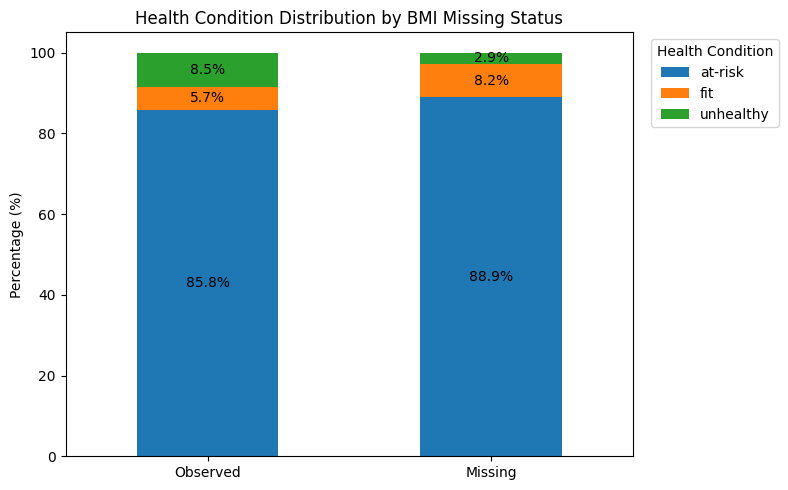

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# BMI 결측 여부 생성
bmi_plot = train.copy()

bmi_plot["BMI Status"] = bmi_plot["bmi"].isna().map({
    False: "Observed",
    True: "Missing"
})

# BMI 결측 여부별 건강상태 비율
bmi_target_ratio = pd.crosstab(
    bmi_plot["BMI Status"],
    bmi_plot["health_condition"],
    normalize="index"
) * 100

# 순서 지정
bmi_target_ratio = bmi_target_ratio.loc[
    ["Observed", "Missing"],
    ["at-risk", "fit", "unhealthy"]
]

# 시각화
ax = bmi_target_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health Condition Distribution by BMI Missing Status")
plt.xlabel("")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Health Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# 각 구간에 퍼센트 표시
for container in ax.containers:
    labels = [
        f"{v:.1f}%" if v >= 2 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/content/bmi_missing_health_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

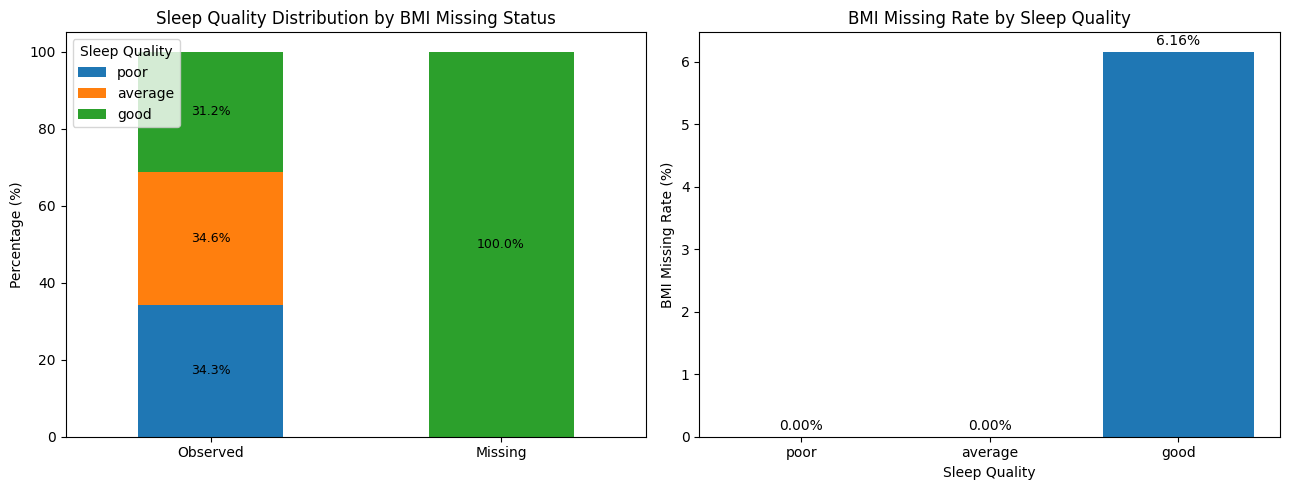

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# BMI 결측 여부 생성
bmi_plot = train.copy()

bmi_plot["BMI Status"] = bmi_plot["bmi"].isna().map({
    False: "Observed",
    True: "Missing"
})

# 1) BMI 결측 여부별 sleep_quality 구성비
sleep_quality_ratio = pd.crosstab(
    bmi_plot["BMI Status"],
    bmi_plot["sleep_quality"],
    normalize="index"
) * 100

sleep_quality_ratio = sleep_quality_ratio.loc[
    ["Observed", "Missing"],
    ["poor", "average", "good"]
]

# 2) sleep_quality별 BMI 결측률
bmi_missing_rate = (
    train.groupby("sleep_quality")["bmi"]
    .apply(lambda x: x.isna().mean() * 100)
    .reindex(["poor", "average", "good"])
)

# 시각화
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# 왼쪽: sleep_quality 구성비
sleep_quality_ratio.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title(
    "Sleep Quality Distribution by BMI Missing Status"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(
    title="Sleep Quality",
    loc="upper left"
)

# 숫자 표시
for container in axes[0].containers:
    labels = [
        f"{v:.1f}%" if v >= 2 else ""
        for v in container.datavalues
    ]

    axes[0].bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# 오른쪽: sleep_quality별 BMI 결측률
bars = axes[1].bar(
    bmi_missing_rate.index,
    bmi_missing_rate.values
)

axes[1].set_title(
    "BMI Missing Rate by Sleep Quality"
)
axes[1].set_xlabel("Sleep Quality")
axes[1].set_ylabel("BMI Missing Rate (%)")

for bar, value in zip(
    bars,
    bmi_missing_rate.values
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/content/bmi_missing_sleep_quality_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()